In [1]:
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [2]:
!gdown --id 1pYHvhzRYaolymRZYWmxFdylGOR-RgyWn #Download File

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1pYHvhzRYaolymRZYWmxFdylGOR-RgyWn
To: /content/Rakamin Bootcamp - Dataset - Promotion Dataset.csv
100% 35.5k/35.5k [00:00<00:00, 70.6MB/s]


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('Rakamin Bootcamp - Dataset - Promotion Dataset.csv', sep = ';')
df.head()

,Employee_ID,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Current_Position_Level,Promotion_Eligible
0,EMP0001,24.0,21.0,2.0,44.0,42.0,19.0,61.0,Junior,0.0
1,EMP0002,50.0,8.0,5.0,45.0,66.0,11.0,6.0,Junior,0.0
2,EMP0003,56.0,9.0,5.0,19.0,96.0,6.0,86.0,Lead,0.0
3,EMP0004,39.0,24.0,4.0,51.0,16.0,6.0,52.0,Senior,0.0
4,EMP0005,41.0,NaN,4.0,64.0,57.0,16.0,59.0,Junior,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             1000 non-null   object 
 1   Age                     950 non-null    float64
 2   Years_at_Company        951 non-null    float64
 3   Performance_Score       950 non-null    float64
 4   Leadership_Score        950 non-null    float64
 5   Training_Hours          950 non-null    float64
 6   Projects_Handled        950 non-null    float64
 7   Peer_Review_Score       950 non-null    float64
 8   Current_Position_Level  950 non-null    object 
 9   Promotion_Eligible      950 non-null    float64
dtypes: float64(8), object(2)
memory usage: 78.3+ KB


# Handling Missing Value

In [6]:
# Imputasi missing value dengan median pada Age, Years_at_Company, dan Training_Hours
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Years_at_Company'].fillna(df['Years_at_Company'].median(), inplace=True)
df['Training_Hours'].fillna(df['Training_Hours'].median(), inplace=True)

# Imputasi missing value dengan mean pada Performance_Score, Leadership_Score, Projects_Handled, dan Peer_Review_Score
df['Performance_Score'].fillna(df['Performance_Score'].mean(), inplace=True)
df['Leadership_Score'].fillna(df['Leadership_Score'].mean(), inplace=True)
df['Projects_Handled'].fillna(df['Projects_Handled'].mean(), inplace=True)
df['Peer_Review_Score'].fillna(df['Peer_Review_Score'].mean(), inplace=True)

# Imputasi missing value dengan modus pada Current_Position_Level
df['Current_Position_Level'].fillna(df['Current_Position_Level'].mode()[0], inplace=True)

# Drop baris yang memiliki missing value Promotion_Eligible
df.dropna(subset=['Promotion_Eligible'], inplace=True)

# Handling Data Type

In [7]:
df['Promotion_Eligible'] = df['Promotion_Eligible'].fillna(0).astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             950 non-null    object 
 1   Age                     950 non-null    float64
 2   Years_at_Company        950 non-null    float64
 3   Performance_Score       950 non-null    float64
 4   Leadership_Score        950 non-null    float64
 5   Training_Hours          950 non-null    float64
 6   Projects_Handled        950 non-null    float64
 7   Peer_Review_Score       950 non-null    float64
 8   Current_Position_Level  950 non-null    object 
 9   Promotion_Eligible      950 non-null    int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 81.6+ KB


# Handling Outlier

In [8]:
num_cols = [
    'Age', 'Years_at_Company', 'Training_Hours',
    'Performance_Score', 'Leadership_Score',
    'Peer_Review_Score', 'Projects_Handled'
]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Menampilkan jumlah outlier
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers} outlier(s) ditemukan")
    print(f"Range: [{lower}, {upper}]\n")

Age: 4 outlier(s) ditemukan
Range: [6.5, 74.5]

Years_at_Company: 2 outlier(s) ditemukan
Range: [-13.0, 43.0]

Training_Hours: 4 outlier(s) ditemukan
Range: [-87.0, 289.0]

Performance_Score: 0 outlier(s) ditemukan
Range: [-1.0, 7.0]

Leadership_Score: 0 outlier(s) ditemukan
Range: [-41.375, 141.625]

Peer_Review_Score: 0 outlier(s) ditemukan
Range: [-46.5, 149.5]

Projects_Handled: 0 outlier(s) ditemukan
Range: [-7.5, 28.5]



In [9]:
df_clean = df.copy()

# Kolom yang memiliki outliers
cols = ['Age', 'Years_at_Company', 'Training_Hours']

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter hanya nilai dalam batas
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

In [10]:
# Menghapus baris dengan anomali Years_at_Company = -5
df_clean = df_clean[df_clean['Years_at_Company'] != -5]

In [11]:
df_clean.describe()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible
count,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000
mean,40.700745,14.796592,2.962231,50.123986,100.701810,9.975284,51.005233,0.293930
std,10.701459,8.559596,1.389385,27.753353,56.458761,5.491168,28.179603,0.455803
min,10.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,8.000000,2.000000,27.500000,54.000000,6.000000,27.000000,0.000000
50%,41.000000,15.000000,3.000000,50.117895,102.500000,10.000000,51.227368,0.000000
75%,49.000000,22.000000,4.000000,73.000000,147.000000,15.000000,76.000000,1.000000
max,59.000000,40.000000,5.000000,99.000000,199.000000,19.000000,99.000000,1.000000


# Option Feature Engineering

## Training Level

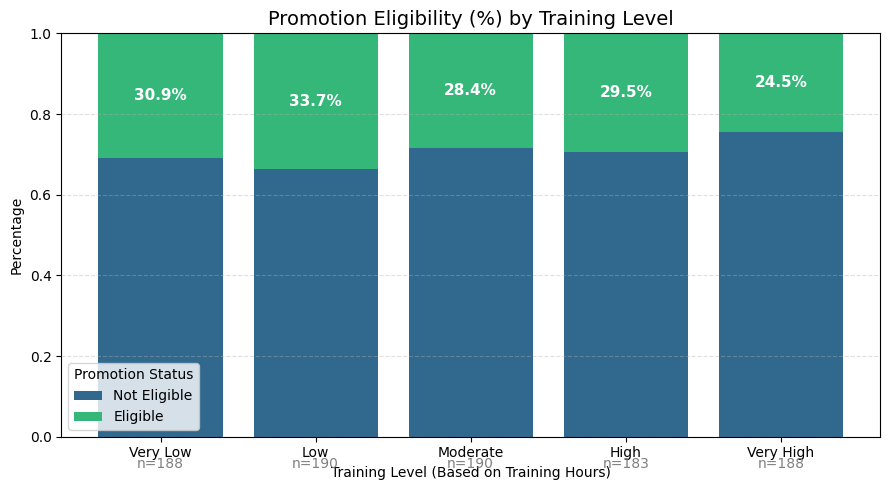

In [12]:
# Membuat Training_Level pakai qcut (bagi per kuartil)
import matplotlib.pyplot as plt
import seaborn as sns

df_clean['Training_Level'] = pd.qcut(df_clean['Training_Hours'],q=5,  # bagi menjadi 5 kelompok sama banyak
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'])

# Menghitung proporsi promotion per kategori
prop = (df_clean.groupby('Training_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index())

# Mengubah ke format pivot untuk stacked bar
prop_pivot = prop.pivot(index='Training_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # pastikan urut: Not Eligible, Eligible

# Menghitung jumlah data per kategori
counts = df_clean['Training_Level'].value_counts().reindex(prop_pivot.index)

plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible (stacked di atasnya)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Label jumlah data (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Format dan tampilan ---
plt.title('Promotion Eligibility (%) by Training Level', fontsize=14)
plt.xlabel('Training Level (Based on Training Hours)')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [13]:
print('Range Nilai Training_Hours')
pd.qcut(df_clean['Training_Hours'], q=5).value_counts(sort=False)

Range Nilai Training_Hours


,count
Training_Hours,
"(-0.001, 41.6]",188
"(41.6, 86.0]",190
"(86.0, 117.0]",190
"(117.0, 160.4]",183
"(160.4, 199.0]",188


## Leadership_Level

In [14]:
df_clean['Leadership_Level'] = pd.qcut(df_clean['Leadership_Score'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
display(df_clean['Leadership_Level'].value_counts())

,count
Leadership_Level,
Medium,252
Low,235
Very High,232
High,220


In [15]:
print('Range Nilai Leadership_Level')
pd.qcut(df_clean['Leadership_Score'], q=4).value_counts(sort=False)

Range Nilai Leadership_Level


,count
Leadership_Score,
"(-0.001, 27.5]",235
"(27.5, 50.118]",252
"(50.118, 73.0]",220
"(73.0, 99.0]",232


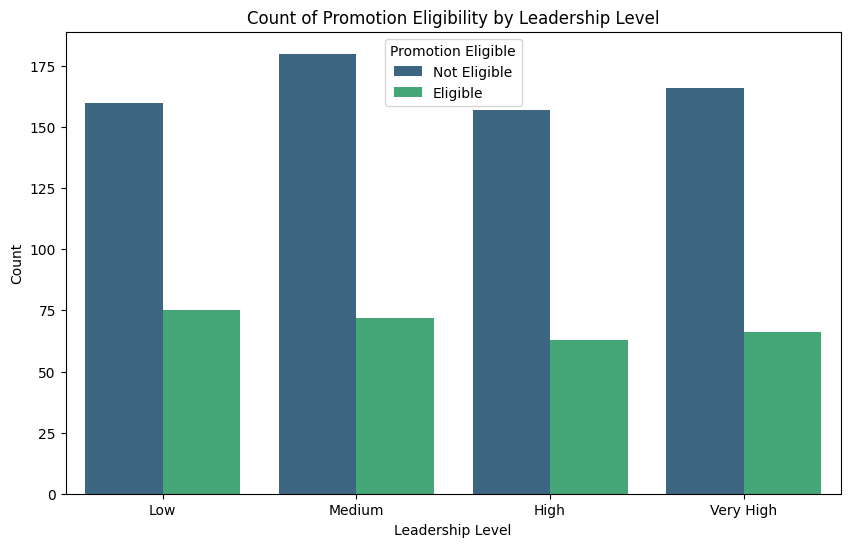

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Leadership_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Leadership Level')
plt.xlabel('Leadership Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.show()

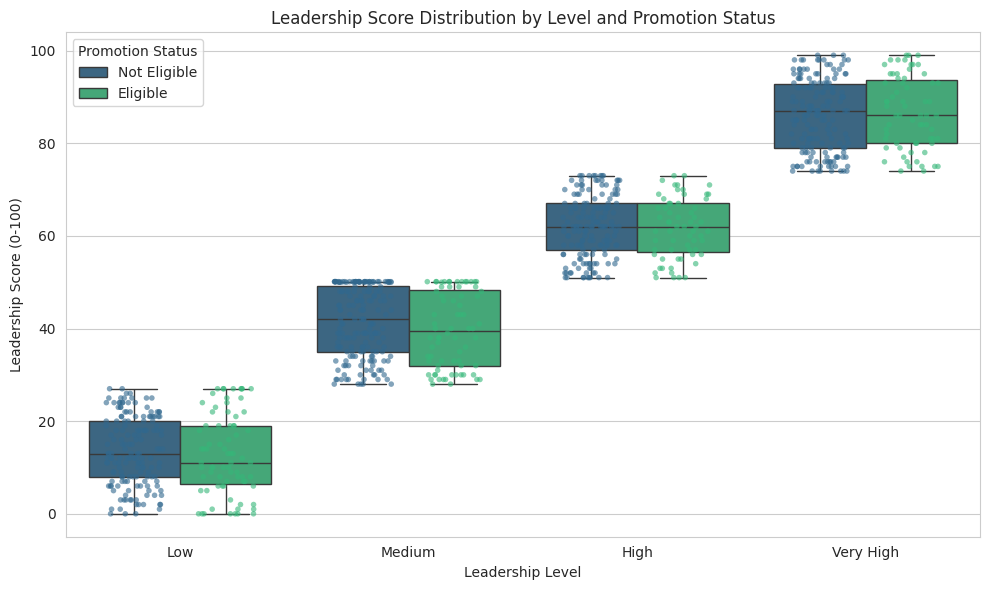

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Boxplot: menunjukkan distribusi Leadership Score per level
sns.boxplot(
    data=df_clean,
    x='Leadership_Level',
    y='Leadership_Score',
    hue='Promotion_Eligible',
    palette='viridis',
    showfliers=False  # hilangkan outlier biar rapi
)

# Stripplot: overlay titik individual untuk menunjukkan sebaran
sns.stripplot(
    data=df_clean,
    x='Leadership_Level',
    y='Leadership_Score',
    hue='Promotion_Eligible',
    dodge=True,        # pisahkan titik antar kategori hue
    jitter=0.25,       # sebar titik biar tidak tumpuk
    palette='viridis',
    alpha=0.6,
    size=4,
    linewidth=0
)

# Hapus legenda duplikat
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:2], ['Not Eligible', 'Eligible'], title='Promotion Status')

plt.title('Leadership Score Distribution by Level and Promotion Status')
plt.xlabel('Leadership Level')
plt.ylabel('Leadership Score (0-100)')
plt.tight_layout()
plt.show()

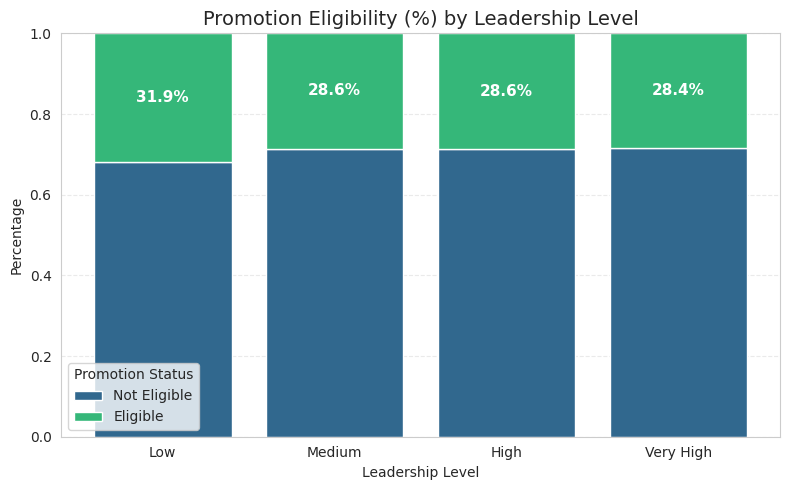

In [18]:
#Stacked Bar Leadership Level
prop = (df_clean.groupby('Leadership_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index())

# Pivot agar jadi format wide (0/1 sebagai kolom)
prop_pivot = prop.pivot(index='Leadership_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # pastikan urutan 0 dulu, lalu 1

#Plot
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar untuk Not Eligible (0)
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar untuk Eligible (1) ditumpuk di atas 0
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# % untuk Eligible
for idx, val in enumerate(prop_pivot[1]):
    total_height = prop_pivot.iloc[idx, 0] + val
    plt.text(
        idx,                        # posisi x
        prop_pivot.iloc[idx, 0] + val / 2,   # posisi y di tengah segmen eligible
        f"{val*100:.1f}%",          # label persentase
        ha='center', va='center', color='white', fontsize=11, fontweight='bold')

plt.title('Promotion Eligibility (%) by Leadership Level', fontsize=14)
plt.xlabel('Leadership Level')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Project_Level


In [19]:
df_clean['Project_per_Years'] = df_clean['Projects_Handled'] / (df_clean['Years_at_Company'] + 1)

In [20]:
df_clean['Project_Level'] = pd.qcut(df_clean['Project_per_Years'],
                              q=4,
                              labels=['Low', 'Moderate', 'High', 'Very High'])

In [21]:
df_clean['Project_Level'].value_counts(normalize=True)


,proportion
Project_Level,
Moderate,0.251331
Low,0.250266
High,0.250266
Very High,0.248136


In [22]:
print('Range Nilai Project_Level')
pd.qcut(df_clean['Project_per_Years'], q=4).value_counts(sort=False)

Range Nilai Project_Level


,count
Project_per_Years,
"(-0.001, 0.359]",235
"(0.359, 0.636]",236
"(0.636, 1.154]",235
"(1.154, 19.0]",233


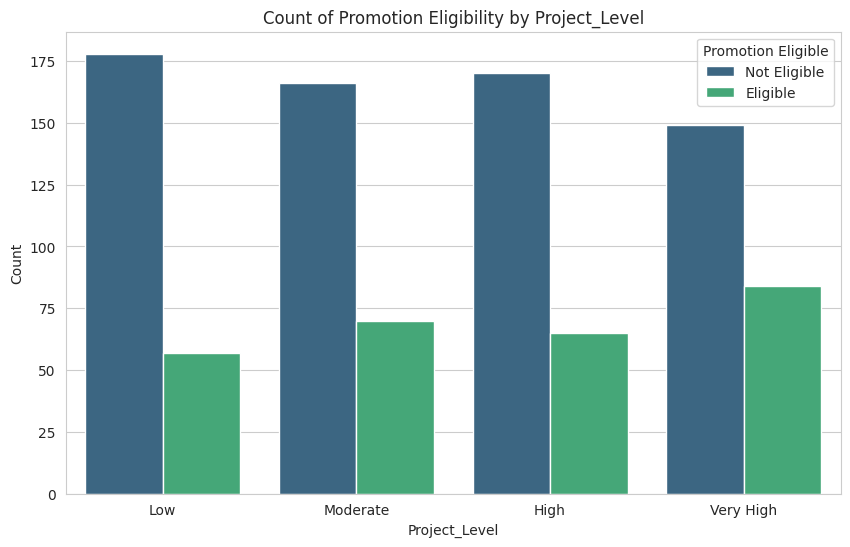

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Project_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Project_Level')
plt.xlabel('Project_Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.show()

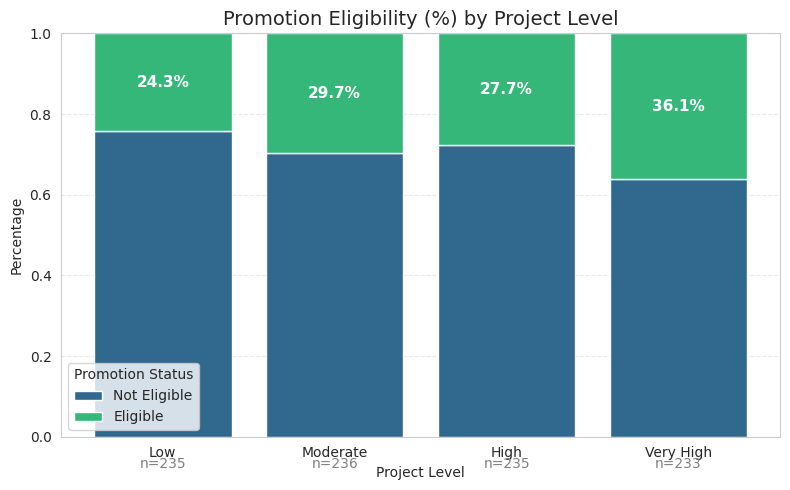

In [24]:
#Stacked Bar

# Proporsi promotion per kategori Project_Level
prop = (
    df_clean.groupby('Project_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index())

# Pivot agar 0 dan 1 jadi kolom
prop_pivot = prop.pivot(index='Project_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urutan 0 (Not Eligible), lalu 1 (Eligible)

# Hitung jumlah total per kategori (untuk label jumlah)
counts = df_clean['Project_Level'].value_counts().reindex(prop_pivot.index)

plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible di atasnya (stacked)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Label % di tengah segmen Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Jumlah total di bawah
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

plt.title('Promotion Eligibility (%) by Project Level', fontsize=14)
plt.xlabel('Project Level')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

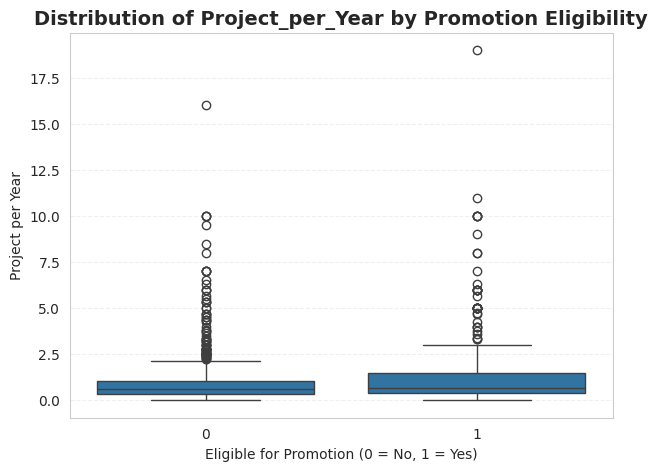

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.boxplot(
    x='Promotion_Eligible',
    y='Project_per_Years',
    data=df_clean,
    #palette={0:'#e74c3c', 1:'#2ecc71'} # Changed keys to integers 0 and 1
)

plt.title('Distribution of Project_per_Year by Promotion Eligibility', fontsize=14, weight='bold')
plt.xlabel('Eligible for Promotion (0 = No, 1 = Yes)')
plt.ylabel('Project per Year')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Tenure Level



In [26]:
df_clean['Tenure_Level'] = pd.qcut(df_clean['Years_at_Company'],
    q = 4,
    labels=['New', 'Mid', 'Senior', 'Veteran'])
df_clean['Tenure_Level'].value_counts()

,count
Tenure_Level,
New,256
Mid,253
Veteran,225
Senior,205


In [27]:
print('Range Nilai Tenure_Level')
pd.qcut(df_clean['Years_at_Company'], q=4).value_counts(sort=False)

Range Nilai Tenure_Level


,count
Years_at_Company,
"(-0.001, 8.0]",256
"(8.0, 15.0]",253
"(15.0, 22.0]",205
"(22.0, 40.0]",225


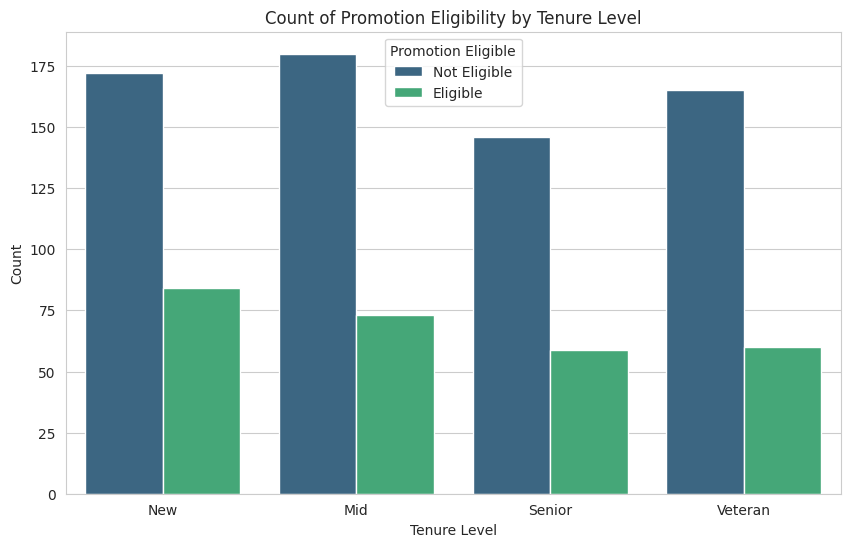

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Tenure_Level', hue='Promotion_Eligible', palette='viridis')

plt.title('Count of Promotion Eligibility by Tenure Level')
plt.xlabel('Tenure Level')
plt.ylabel('Count')
plt.legend(title='Promotion Eligible', labels=['Not Eligible', 'Eligible'])
plt.show()

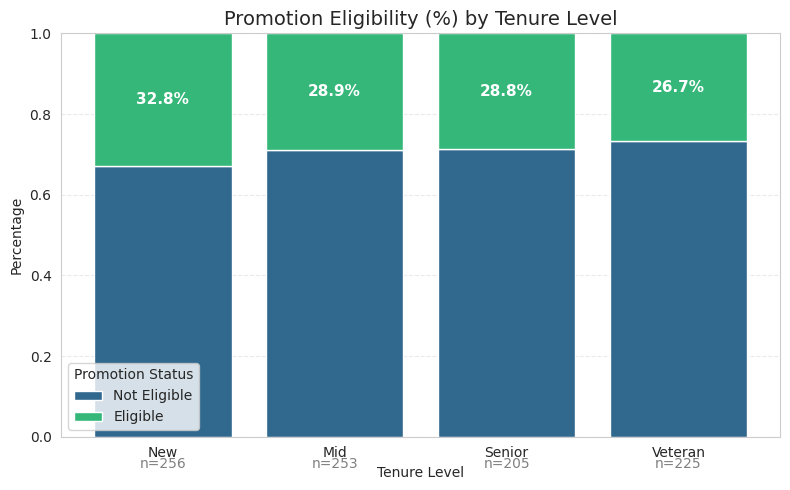

In [29]:
#Stacked Bar
# Proporsi promotion per kategori Tenure_Level
prop = (df_clean.groupby('Tenure_Level')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index())

# Ubah jadi pivot (biar mudah di-plot)
prop_pivot = prop.pivot(index='Tenure_Level', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urut: Not Eligible (0), Eligible (1)

# Hitung total data per kategori (untuk label "n=")
counts = df_clean['Tenure_Level'].value_counts().reindex(prop_pivot.index)

# --- Plot ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar bagian bawah: Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar bagian atas: Eligible (stacked)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Tambahkan label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Tambahkan jumlah total (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Format dan tampilan ---
plt.title('Promotion Eligibility (%) by Tenure Level', fontsize=14)
plt.xlabel('Tenure Level')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Age Group

In [30]:
print('Range Age_Group')
pd.qcut(df_clean['Age'], q=4).value_counts(sort=False)

Range Age_Group


,count
Age,
"(9.999, 32.0]",247
"(32.0, 41.0]",257
"(41.0, 49.0]",206
"(49.0, 59.0]",229


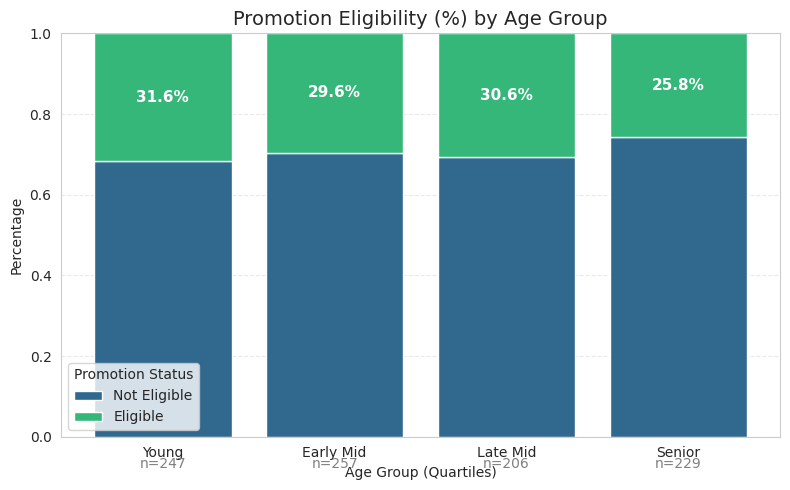

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat Age_Group dengan qcut (pembagian berdasarkan kuartil data usia)
df_clean['Age_Group'] = pd.qcut(
    df_clean['Age'],
    q=4,  # bagi menjadi 4 grup
    labels=['Young', 'Early Mid', 'Late Mid', 'Senior']
)

# Hitung proporsi promotion per kelompok usia
prop = (
    df_clean.groupby('Age_Group')['Promotion_Eligible']
    .value_counts(normalize=True)
    .rename('Proportion')
    .reset_index()
)

# Ubah ke format pivot untuk stacked bar
prop_pivot = prop.pivot(index='Age_Group', columns='Promotion_Eligible', values='Proportion').fillna(0)
prop_pivot = prop_pivot[[0, 1]]  # urutkan kolom (0=Not Eligible, 1=Eligible)

# Hitung jumlah data per kelompok usia
counts = df_clean['Age_Group'].value_counts().reindex(prop_pivot.index)

# --- Plot ---
plt.figure(figsize=(8, 5))
colors = sns.color_palette("viridis", 2)

# Bar Not Eligible
plt.bar(prop_pivot.index, prop_pivot[0], color=colors[0], label='Not Eligible')

# Bar Eligible di atasnya (stacked)
plt.bar(prop_pivot.index, prop_pivot[1], bottom=prop_pivot[0], color=colors[1], label='Eligible')

# Tambahkan label % di tengah bagian Eligible
for i, val in enumerate(prop_pivot[1]):
    plt.text(i, prop_pivot[0].iloc[i] + val / 2, f"{val*100:.1f}%",
             ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Tambahkan jumlah data (n) di bawah batang
for i, total in enumerate(counts):
    plt.text(i, -0.05, f"n={total}", ha='center', va='top', fontsize=10, color='gray')

# --- Tampilan akhir ---
plt.title('Promotion Eligibility (%) by Age Group', fontsize=14)
plt.xlabel('Age Group (Quartiles)')
plt.ylabel('Percentage')
plt.ylim(0, 1)
plt.legend(title='Promotion Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Overall Performance Index

In [32]:
df_clean.columns

Index(['Employee_ID', 'Age', 'Years_at_Company', 'Performance_Score',
       'Leadership_Score', 'Training_Hours', 'Projects_Handled',
       'Peer_Review_Score', 'Current_Position_Level', 'Promotion_Eligible',
       'Training_Level', 'Leadership_Level', 'Project_per_Years',
       'Project_Level', 'Tenure_Level', 'Age_Group'],
      dtype='object')

In [33]:
from sklearn.preprocessing import MinMaxScaler

# Pastikan kolomnya ada:
cols = ['Performance_Score', 'Project_per_Years', 'Training_Hours',
        'Leadership_Score', 'Peer_Review_Score']

# Normalisasi 0–1
#scaler = MinMaxScaler()
# Apply scaler to df_clean since 'Project_per_Years' exists there
#df_clean[[col + '_norm' for col in cols]] = scaler.fit_transform(df_clean[cols])

# Buat Overall Performance Index (bobot bisa disesuaikan)
df_clean['Overall_Performance_Index'] = (
    0.20 * df_clean['Performance_Score'] +     # kinerja utama
    0.35 * df_clean['Project_per_Years'] +      # produktivitas
    0.20 * df_clean['Training_Hours'] +        # pengembangan diri
    0.10 * df_clean['Leadership_Score'] +      # kepemimpinan
    0.15 * df_clean['Peer_Review_Score']       # kerja sama
)

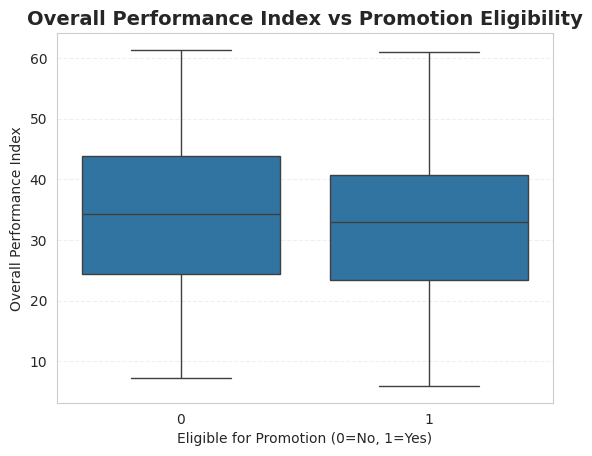

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='Promotion_Eligible',
    y='Overall_Performance_Index',
    data=df_clean,
    #palette={0:'#e74c3c', 1:'#2ecc71'}
)
plt.title('Overall Performance Index vs Promotion Eligibility', fontsize=14, weight='bold')
plt.xlabel('Eligible for Promotion (0=No, 1=Yes)')
plt.ylabel('Overall Performance Index')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Conclusion

Feature Engineering yang dimasukkan (data categorical-ordinal):


*   Training level: karena terlihat ada sedikit perbedaan, urutan 2nd lebih besar promosinya
*   Leadership level: ada perbedaan, level leadership rendah lebih besar promosinya
*   Project level : ada perbedaan, project level tinggi lebih besar promosinya
*   Tenure level: ada perbedaan,tenure lebih rendah lebih besar promosinya
*   Age group: lebih muda, lebih besar % promosinya

In [35]:
#drop kolom yang tidak digunakan dari data df_clean
columns_to_drop = ['Overall_Performance_Index','Employee_ID']

# Apply in pipeline
df_clean1 = df_clean.drop(columns=columns_to_drop)

In [36]:
df_clean1.head()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Current_Position_Level,Promotion_Eligible,Training_Level,Leadership_Level,Project_per_Years,Project_Level,Tenure_Level,Age_Group
0,24.0,21.0,2.0,44.0,42.0,19.0,61.0,Junior,0,Low,Medium,0.863636,High,Senior,Young
1,50.0,8.0,5.0,45.0,66.0,11.0,6.0,Junior,0,Low,Medium,1.222222,Very High,New,Senior
2,56.0,9.0,5.0,19.0,96.0,6.0,86.0,Lead,0,Moderate,Low,0.600000,Moderate,Mid,Senior
3,39.0,24.0,4.0,51.0,16.0,6.0,52.0,Senior,0,Very Low,High,0.240000,Low,Veteran,Early Mid
4,41.0,15.0,4.0,64.0,57.0,16.0,59.0,Junior,0,Low,High,1.000000,High,Mid,Early Mid


In [37]:
df_clean1.describe()

,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Project_per_Years
count,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000,939.000000
mean,40.700745,14.796592,2.962231,50.123986,100.701810,9.975284,51.005233,0.293930,1.203685
std,10.701459,8.559596,1.389385,27.753353,56.458761,5.491168,28.179603,0.455803,1.789169
min,10.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,8.000000,2.000000,27.500000,54.000000,6.000000,27.000000,0.000000,0.358571
50%,41.000000,15.000000,3.000000,50.117895,102.500000,10.000000,51.227368,0.000000,0.636364
75%,49.000000,22.000000,4.000000,73.000000,147.000000,15.000000,76.000000,1.000000,1.153846
max,59.000000,40.000000,5.000000,99.000000,199.000000,19.000000,99.000000,1.000000,19.000000


# Feature Transformation

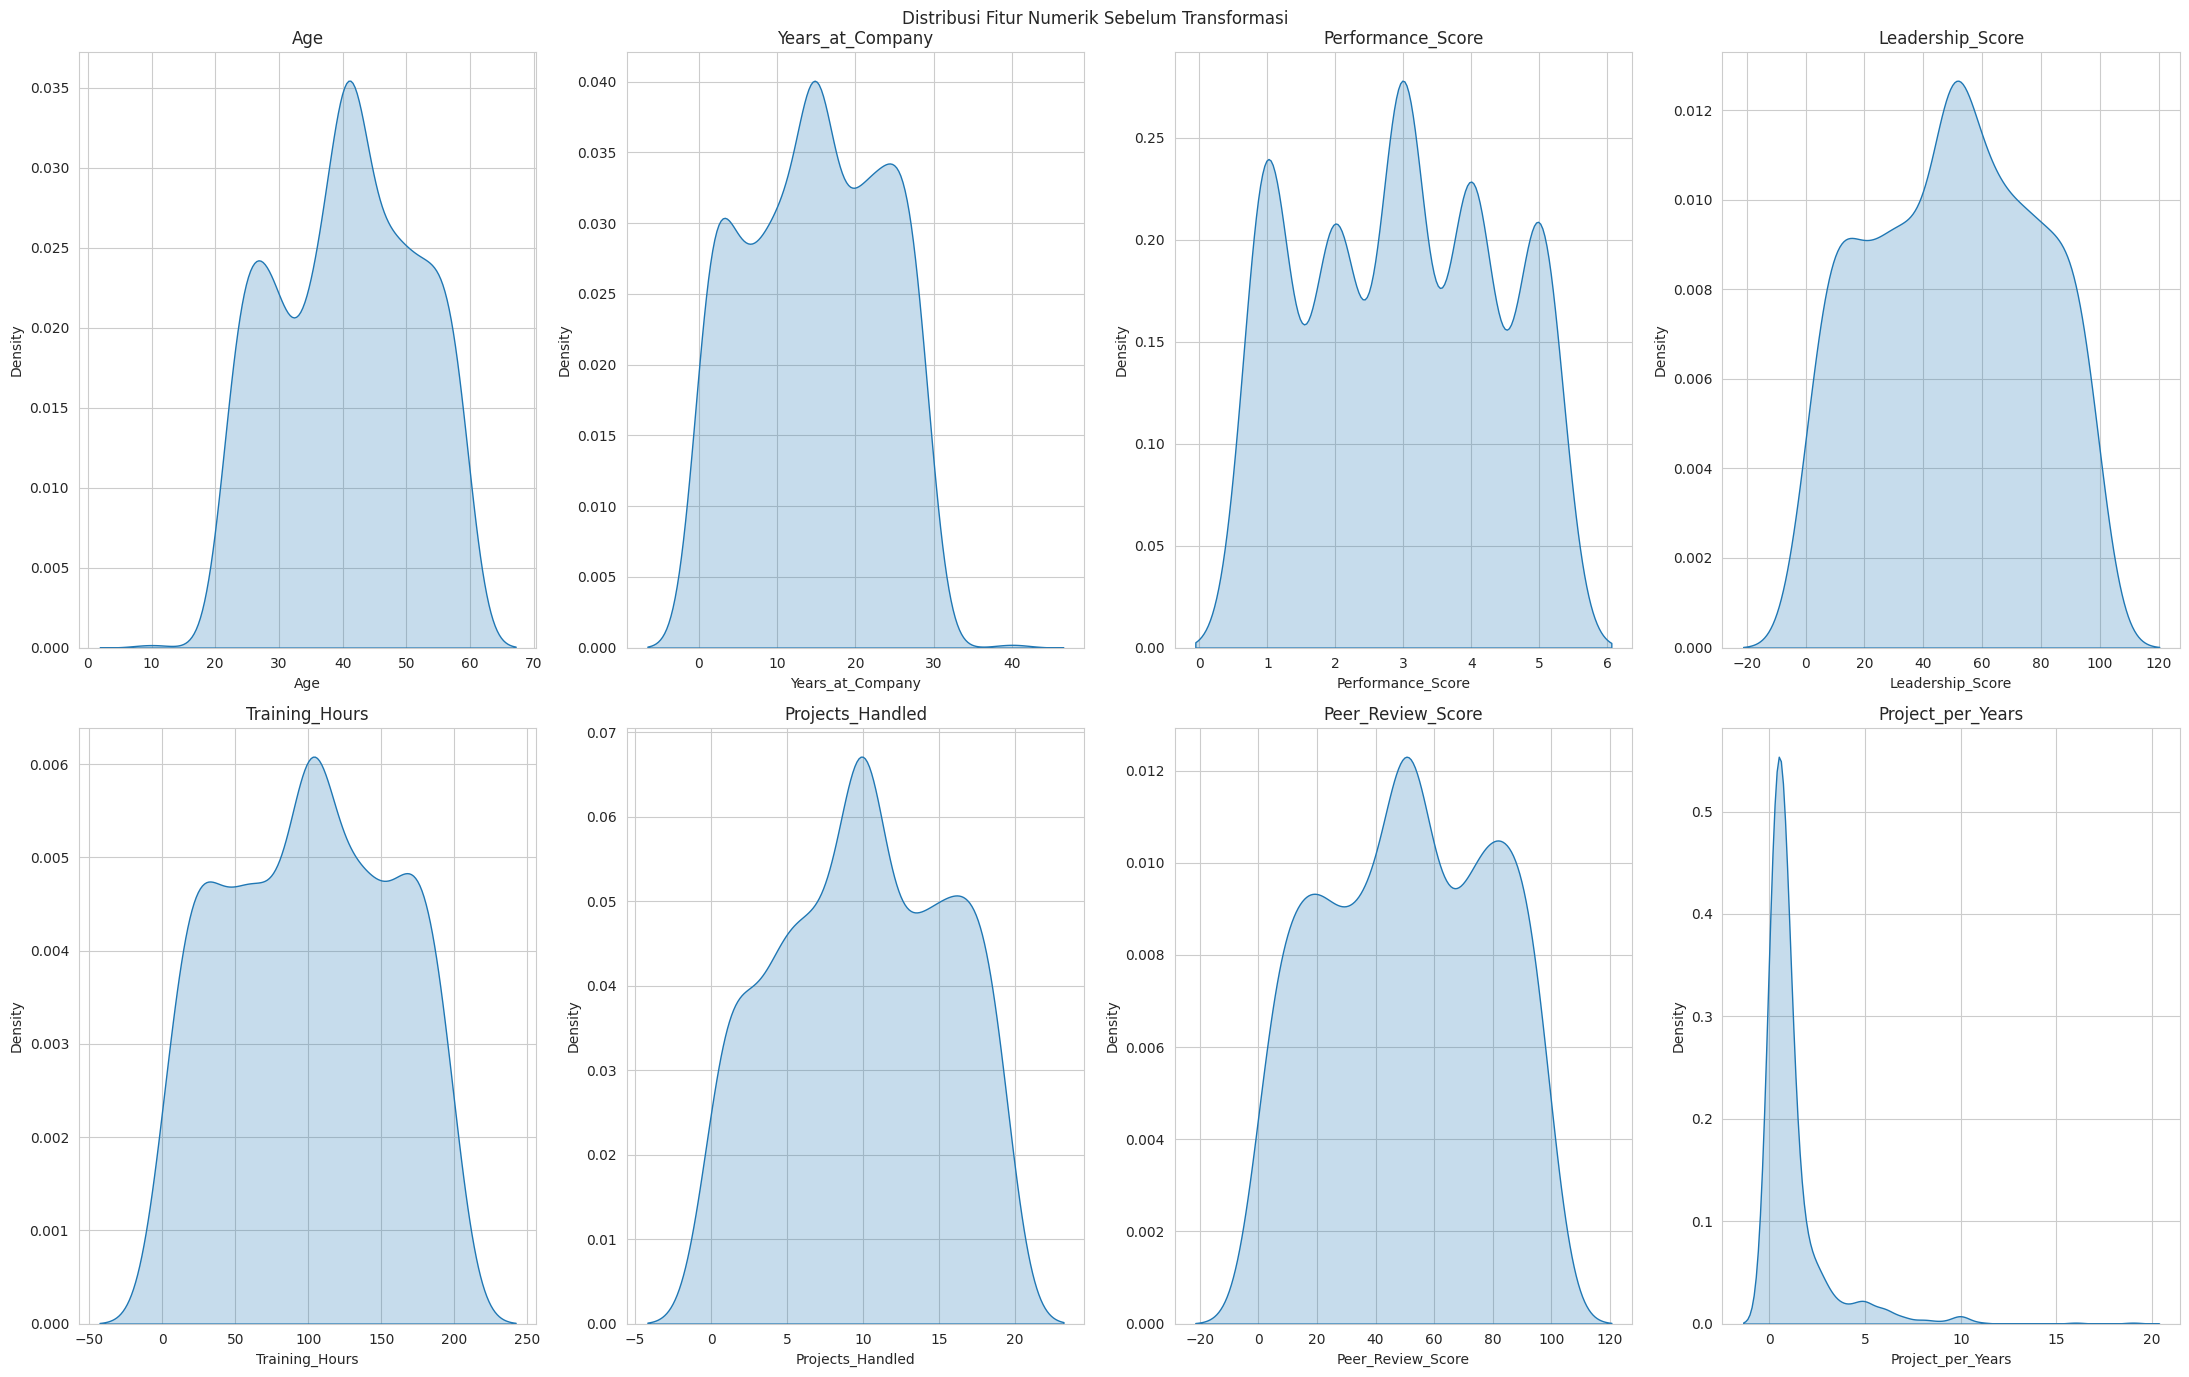

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifikasi tipe fitur
num_features = ['Age', 'Years_at_Company', 'Performance_Score','Leadership_Score', 'Training_Hours',
    'Projects_Handled', 'Peer_Review_Score', 'Project_per_Years']
fig, axes = plt.subplots(2, 4, figsize=(22, 14))
axes=axes.flatten()
for i, col in enumerate (num_features):
    sns.kdeplot(data=df_clean1, x=col, fill=True, ax=axes[i])
    axes[i].set_title (col)

#mhapus kolom yang tidak diperlukan
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur Numerik Sebelum Transformasi')


plt.tight_layout()
plt.show()

## Log Transformation


Dua opsi, 1 dilakukan log transformation dan 1 lagi tanpa log transformation

log transformasi untuk Age, Projecy_per_Years, dan Years_at_Company

In [39]:
#dengan log transformation dari df_clean1
import numpy as np
import pandas as pd
df_logtrans = df_clean1.copy()

cols_to_log = ['Age', 'Years_at_Company', 'Project_per_Years']
cols_to_log = [c for c in cols_to_log if c in df_logtrans.columns]

df_logtrans[cols_to_log] = np.log1p(df_logtrans[cols_to_log])

## One Hot Encoding

In [40]:
cat_features = [
    'Current_Position_Level',
    'Training_Level',
    'Leadership_Level',
    'Project_Level',
    'Tenure_Level',
    'Age_Group']

### OHE dengan log transform

In [41]:
#dengan log transfrom
df_encod = pd.get_dummies(df_logtrans,
                            columns=cat_features,
                            drop_first=True)  # drop_first
print(df_encod.shape)
df_encod.head()

(939, 28)


,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Project_per_Years,Current_Position_Level_Lead,...,Leadership_Level_Very High,Project_Level_Moderate,Project_Level_High,Project_Level_Very High,Tenure_Level_Mid,Tenure_Level_Senior,Tenure_Level_Veteran,Age_Group_Early Mid,Age_Group_Late Mid,Age_Group_Senior
0,3.218876,3.091042,2.0,44.0,42.0,19.0,61.0,0,0.622530,False,...,False,False,True,False,False,True,False,False,False,False
1,3.931826,2.197225,5.0,45.0,66.0,11.0,6.0,0,0.798508,False,...,False,False,False,True,False,False,False,False,False,True
2,4.043051,2.302585,5.0,19.0,96.0,6.0,86.0,0,0.470004,True,...,False,True,False,False,True,False,False,False,False,True
3,3.688879,3.218876,4.0,51.0,16.0,6.0,52.0,0,0.215111,False,...,False,False,False,False,False,False,True,True,False,False
4,3.737670,2.772589,4.0,64.0,57.0,16.0,59.0,0,0.693147,False,...,False,False,True,False,True,False,False,True,False,False


### OHE tanpa log transform

In [42]:
#tanpa log transfrom
df_encod1 = pd.get_dummies(df_clean1,
                            columns=cat_features,
                            drop_first=True)  # drop_first
print(df_encod1.shape)
df_encod1.head()

(939, 28)


,Age,Years_at_Company,Performance_Score,Leadership_Score,Training_Hours,Projects_Handled,Peer_Review_Score,Promotion_Eligible,Project_per_Years,Current_Position_Level_Lead,...,Leadership_Level_Very High,Project_Level_Moderate,Project_Level_High,Project_Level_Very High,Tenure_Level_Mid,Tenure_Level_Senior,Tenure_Level_Veteran,Age_Group_Early Mid,Age_Group_Late Mid,Age_Group_Senior
0,24.0,21.0,2.0,44.0,42.0,19.0,61.0,0,0.863636,False,...,False,False,True,False,False,True,False,False,False,False
1,50.0,8.0,5.0,45.0,66.0,11.0,6.0,0,1.222222,False,...,False,False,False,True,False,False,False,False,False,True
2,56.0,9.0,5.0,19.0,96.0,6.0,86.0,0,0.600000,True,...,False,True,False,False,True,False,False,False,False,True
3,39.0,24.0,4.0,51.0,16.0,6.0,52.0,0,0.240000,False,...,False,False,False,False,False,False,True,True,False,False
4,41.0,15.0,4.0,64.0,57.0,16.0,59.0,0,1.000000,False,...,False,False,True,False,True,False,False,True,False,False


## Imbalance Handling

### Split data

In [43]:
from sklearn.model_selection import train_test_split

#### Dengan Log transfrom

In [44]:
# Dataset dengan log transform
X = df_encod.drop(['Promotion_Eligible'], axis=1)
y = df_encod['Promotion_Eligible']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Tanpa Log Transfrom

In [45]:
from sklearn.model_selection import train_test_split

X_1 = df_encod1.drop(['Promotion_Eligible'], axis=1)
y_1= df_encod1['Promotion_Eligible']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1,test_size=0.2,stratify=y,random_state=42)

### Imbalance Check

#### Dengan Log Transform

In [46]:
# dengan log transfrom
print('Distribusi kelas sebelum balancing:')
print(y_train.value_counts())
print('\nProporsi kelas:')
print(y_train.value_counts(normalize=True))

Distribusi kelas sebelum balancing:
Promotion_Eligible
0    530
1    221
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
0    0.705726
1    0.294274
Name: proportion, dtype: float64


#### Tanpa log transform

In [47]:
#Tanpa log transform
print('Distribusi kelas sebelum balancing:')
print(y_train_1.value_counts())
print('\nProporsi kelas:')
print(y_train_1.value_counts(normalize=True))

Distribusi kelas sebelum balancing:
Promotion_Eligible
0    530
1    221
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
0    0.705726
1    0.294274
Name: proportion, dtype: float64


### SMOTE

#### Dengan log transfrom

In [48]:
#dengan log transform
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Setelah SMOTE:')
print(y_train_bal.value_counts())
print('\nProporsi kelas:')
print(y_train_bal.value_counts(normalize=True))

Setelah SMOTE:
Promotion_Eligible
1    530
0    530
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
1    0.5
0    0.5
Name: proportion, dtype: float64


#### Tanpa log transform

In [49]:
#tanpa log transform
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal1, y_train_bal1 = smote.fit_resample(X_train_1, y_train_1)

print('Setelah SMOTE:')
print(y_train_bal1.value_counts())
print('\nProporsi kelas:')
print(y_train_bal1.value_counts(normalize=True))

Setelah SMOTE:
Promotion_Eligible
1    530
0    530
Name: count, dtype: int64

Proporsi kelas:
Promotion_Eligible
1    0.5
0    0.5
Name: proportion, dtype: float64


## Standardisasi

### Dengan log transform

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

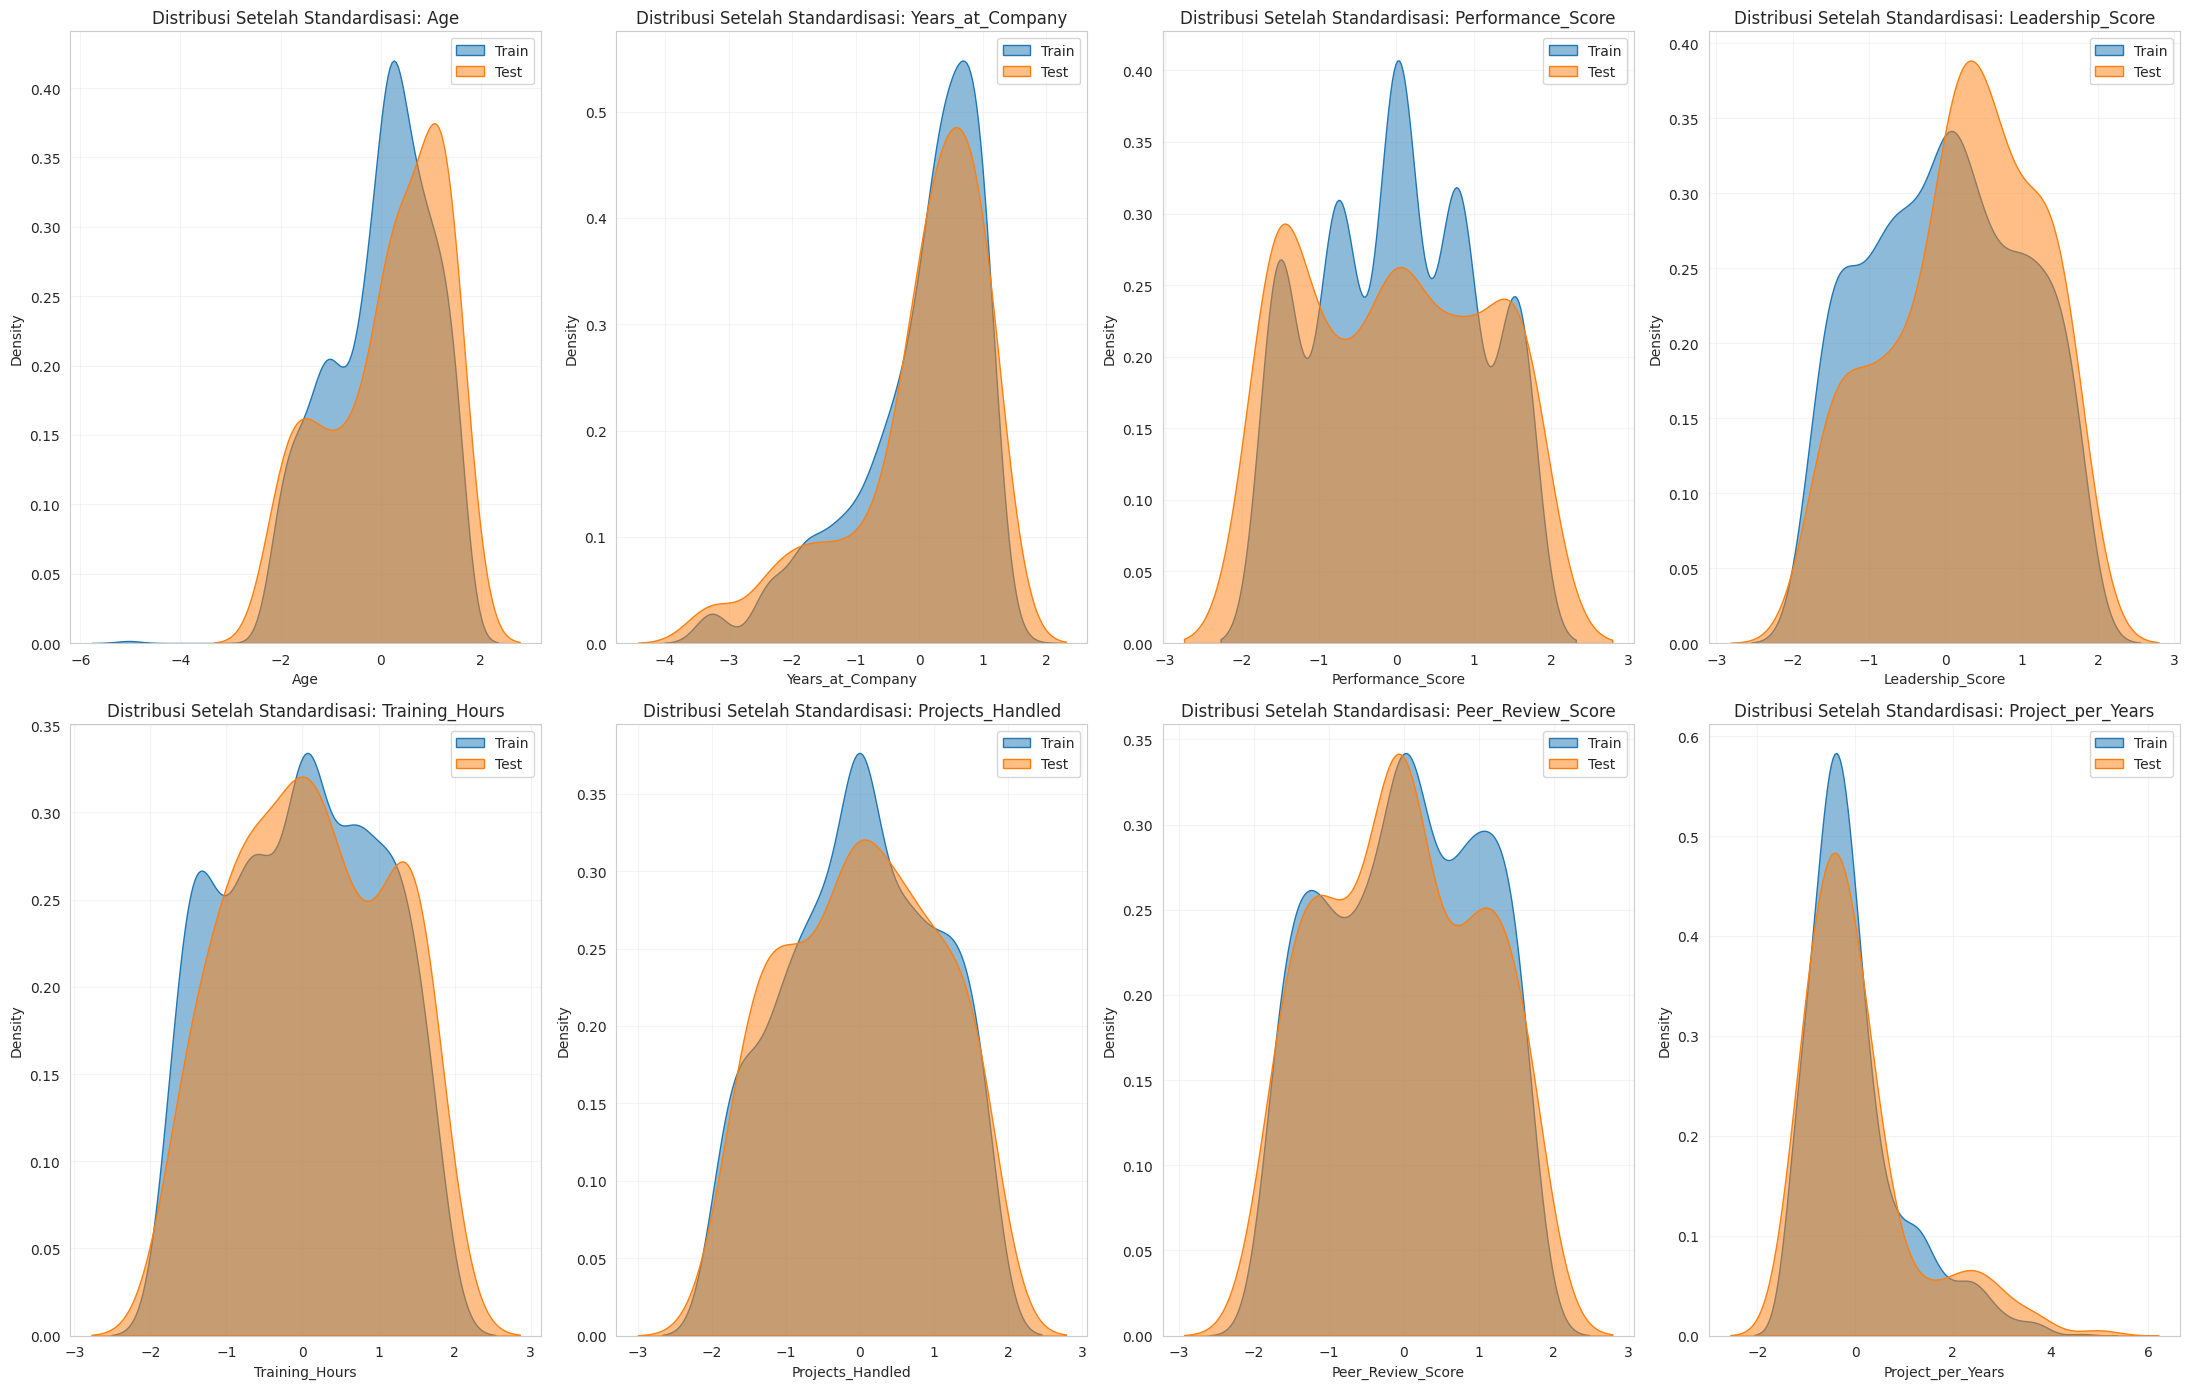

In [51]:
# Grafik hasil log transform dan standardisasi
#Convert scaled data back to DataFrame dengan nama kolom
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_bal.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Plot distribusi training set setelah standardisasi
plt.figure(figsize=(22, 14))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 4, i)
    sns.kdeplot(X_train_scaled_df[col], fill=True, alpha=0.5, label='Train')
    sns.kdeplot(X_test_scaled_df[col], fill=True, alpha=0.5, label='Test')
    plt.title(f'Distribusi Setelah Standardisasi: {col}')
    plt.legend()
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Tanpa log transform

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled1 = scaler.fit_transform(X_train_bal1)
X_test_scaled1 = scaler.transform(X_test_1)

# Modelling

In [53]:
# Model & Evaluasi
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns

#### Evaluations Metrics

## Dengan Log Transform

In [54]:
X_train_scaled.shape, X_test_scaled.shape, y_train_bal.shape, y_test.shape

((1060, 27), (188, 27), (1060,), (188,))

In [55]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, fbeta_score
from sklearn.model_selection import cross_validate

def evaluate_model_summary(model, X_train, X_test, y_train, y_test, model_name=""):
    """
    Function untuk evaluasi model dan return summary dalam bentuk DataFrame
    """
    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_proba_train = model.predict_proba(X_train)[:, 1]
    y_proba_test = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    metrics_dict = {
        'Model': model_name,
        'Accuracy_Train': accuracy_score(y_train, y_pred_train),
        'Accuracy_Test': accuracy_score(y_test, y_pred_test),
        'Precision_Train': precision_score(y_train, y_pred_train),
        'Precision_Test': precision_score(y_test, y_pred_test),
        'Recall_Train': recall_score(y_train, y_pred_train),
        'Recall_Test': recall_score(y_test, y_pred_test),
        'F1_Train': f1_score(y_train, y_pred_train),
        'F1_Test': f1_score(y_test, y_pred_test),
        'F2_Train': fbeta_score(y_train, y_pred_train, beta=2),
        'F2_Test': fbeta_score(y_test, y_pred_test, beta=2),
        'ROC_AUC_Train': roc_auc_score(y_train, y_proba_train),
        'ROC_AUC_Test': roc_auc_score(y_test, y_proba_test)}

    # Cross Validation Scores
    cv_scores = cross_validate(model, X_train, y_train, cv=5, scoring=['recall', 'roc_auc'], return_train_score=True)

    metrics_dict.update({
        'CV_Recall_Train': cv_scores['train_recall'].mean(),
        'CV_Recall_Test': cv_scores['test_recall'].mean(),
        'CV_ROC_AUC_Train': cv_scores['train_roc_auc'].mean(),
        'CV_ROC_AUC_Test': cv_scores['test_roc_auc'].mean()})

    return pd.DataFrame([metrics_dict])

def print_model_results(results_df):
    """
    Print hasil evaluasi model dalam format tabel yang rapi
    """
    print(f"\n{'='*80}")
    print(f"MODEL EVALUATION RESULTS")
    print(f"{'='*80}")

    # Format dataframe untuk display
    display_df = results_df.round(3).T

    print(display_df)

#### Logistic Regression

In [56]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

print("MODEL 1: LOGISTIC REGRESSION")

# 1. BASELINE MODEL
lr_baseline = LogisticRegression(random_state=42)
lr_baseline.fit(X_train_scaled, y_train_bal)

# Evaluate Baseline
baseline_results = evaluate_model_summary(lr_baseline, X_train_scaled, X_test_scaled, y_train_bal, y_test, "LogReg Baseline")
print_model_results(baseline_results)

MODEL 1: LOGISTIC REGRESSION

MODEL EVALUATION RESULTS
                                0
Model             LogReg Baseline
Accuracy_Train              0.766
Accuracy_Test               0.681
Precision_Train             0.863
Precision_Test              0.419
Recall_Train                0.632
Recall_Test                 0.236
F1_Train                     0.73
F1_Test                     0.302
F2_Train                    0.668
F2_Test                     0.259
ROC_AUC_Train               0.816
ROC_AUC_Test                0.544
CV_Recall_Train             0.654
CV_Recall_Test              0.602
CV_ROC_AUC_Train            0.821
CV_ROC_AUC_Test             0.784


In [57]:
# 2. TUNING MODEL
print("\nTuning Logistic Regression...")
param_dist = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],   # beberapa nilai C
    'solver': ['liblinear', 'lbfgs', 'saga'],  # beberapa solver
    'penalty': ['l1', 'l2'],               # tipe regularisasi
    'max_iter': [1000]
}

lr = LogisticRegression(random_state=42)
rs_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1)

rs_lr.fit(X_train_scaled, y_train_bal)
print(f"Best parameters: {rs_lr.best_params_}")
print(f" Best CV ROC-AUC: {rs_lr.best_score_:.3f}")

# BEST TUNED MODEL
lr_best = rs_lr.best_estimator_

# EVALUATION TUNED MODEL
lr_results = evaluate_model_summary(
    lr_best, X_train_scaled, X_test_scaled, y_train_bal, y_test, "LogReg Tuned")
lr_display = print_model_results(lr_results)


Tuning Logistic Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 1000, 'C': 100}
 Best CV ROC-AUC: 0.787

MODEL EVALUATION RESULTS
                             0
Model             LogReg Tuned
Accuracy_Train            0.76
Accuracy_Test            0.676
Precision_Train          0.847
Precision_Test           0.406
Recall_Train             0.636
Recall_Test              0.236
F1_Train                 0.726
F1_Test                  0.299
F2_Train                 0.669
F2_Test                  0.258
ROC_AUC_Train            0.817
ROC_AUC_Test              0.54
CV_Recall_Train          0.657
CV_Recall_Test           0.611
CV_ROC_AUC_Train         0.822
CV_ROC_AUC_Test          0.787


Hasil Logistic Regression antara baseline dan hasil tuning sama:
1. C ~ 0.83 → mendekati default C=1.0 --> egularisasi hampir sama dengan baseline.
2. penalty='l2' --> sama seperti default LogisticRegression.
3. solver='saga' --> berbeda dengan default (lbfgs), tapi untuk L2 dan skala standar, pengaruhnya minor.

dari 'C': np.logspace(-4, 0, 50), akan dicoba 'C': np.logspace(-4, 2, 100)

In [58]:
# 3. TUNING 2 MODEL
print("\nTuning 2 Logistic Regression...")
param_dist = {
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-4, 2, 100),
    'solver': ['liblinear', 'saga'],
    'class_weight': [None, 'balanced']}

lr = LogisticRegression(max_iter=1000, random_state=42)
rs_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1)

rs_lr.fit(X_train_scaled, y_train_bal)
print(f"Best parameters: {rs_lr.best_params_}")
print(f" Best CV ROC-AUC: {rs_lr.best_score_:.3f}")

# BEST TUNED MODEL
lr_best = rs_lr.best_estimator_

# EVALUATION TUNED MODEL
lr_results = evaluate_model_summary(
    lr_best, X_train_scaled, X_test_scaled, y_train_bal, y_test, "LogReg Tuned 2")
lr_display = print_model_results(lr_results)


Tuning 2 Logistic Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': None, 'C': np.float64(57.223676593502205)}
 Best CV ROC-AUC: 0.787

MODEL EVALUATION RESULTS
                               0
Model             LogReg Tuned 2
Accuracy_Train              0.76
Accuracy_Test              0.676
Precision_Train            0.847
Precision_Test             0.406
Recall_Train               0.636
Recall_Test                0.236
F1_Train                   0.726
F1_Test                    0.299
F2_Train                   0.669
F2_Test                    0.258
ROC_AUC_Train              0.817
ROC_AUC_Test               0.541
CV_Recall_Train            0.656
CV_Recall_Test             0.611
CV_ROC_AUC_Train           0.822
CV_ROC_AUC_Test            0.787


Hasil baseline dan tuning 1 serupa, tuning 2 mengubah paramater C (lebih besar) dengan cross validation, menghasilkan model yang relatif stabil, tetapi recall (0.61) dan AUC test (0.54) masih rendah

Model Logistic Regression belum efektif untuk memprediksi promosi karyawan secara akurat, terutama dalam mengenali talenta potensial (recall rendah).

Artinya, masih banyak karyawan yang layak promosi tidak terdeteksi model.

### XGBoost

In [59]:
#1.Base XGBoost
from xgboost import XGBClassifier

print("MODEL 2: XGBoost")

# 1. BASELINE MODEL
xgb_baseline = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train_scaled, y_train_bal)

# Evaluate Baseline
baseline_results = evaluate_model_summary(xgb_baseline, X_train_scaled, X_test_scaled, y_train_bal, y_test, "XGB Baseline")
print_model_results(baseline_results)

MODEL 2: XGBoost

MODEL EVALUATION RESULTS
                             0
Model             XGB Baseline
Accuracy_Train             1.0
Accuracy_Test            0.633
Precision_Train            1.0
Precision_Test           0.348
Recall_Train               1.0
Recall_Test              0.291
F1_Train                   1.0
F1_Test                  0.317
F2_Train                   1.0
F2_Test                  0.301
ROC_AUC_Train              1.0
ROC_AUC_Test             0.508
CV_Recall_Train            1.0
CV_Recall_Test           0.675
CV_ROC_AUC_Train           1.0
CV_ROC_AUC_Test          0.814


In [61]:
#2. Tuning XGBoost
print("\nTuning XGBoost (Range Moderat)...")

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': np.linspace(0.01, 0.3, 30),
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_lambda': np.logspace(-2, 2, 10)}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1)

rs_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1)

rs_xgb.fit(X_train_scaled, y_train_bal)
print(f"Best parameters: {rs_xgb.best_params_}")
print(f" Best CV ROC-AUC: {rs_xgb.best_score_:.3f}")

# BEST TUNED MODEL
xgb_best = rs_xgb.best_estimator_

# EVALUATION TUNED MODEL
xgb_results = evaluate_model_summary(
    xgb_best, X_train_scaled, X_test_scaled, y_train_bal, y_test, "XGB Tuned")
print_model_results(xgb_results)


Tuning XGBoost (Range Moderat)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.7, 'reg_lambda': np.float64(12.915496650148826), 'n_estimators': 300, 'max_depth': 5, 'learning_rate': np.float64(0.19999999999999998), 'gamma': 0.3, 'colsample_bytree': 0.8}
 Best CV ROC-AUC: 0.826

MODEL EVALUATION RESULTS
                          0
Model             XGB Tuned
Accuracy_Train        0.994
Accuracy_Test         0.622
Precision_Train         1.0
Precision_Test          0.3
Recall_Train          0.989
Recall_Test           0.218
F1_Train              0.994
F1_Test               0.253
F2_Train              0.991
F2_Test               0.231
ROC_AUC_Train           1.0
ROC_AUC_Test           0.49
CV_Recall_Train       0.992
CV_Recall_Test         0.67
CV_ROC_AUC_Train        1.0
CV_ROC_AUC_Test       0.826


In [62]:
#3. Tuning XGBoost 2
print("\nTuning 2 XGBoost (Range Lebih Lebar)...")

param_dist_2 = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [4, 5, 6, 8],
    'learning_rate': np.linspace(0.01, 0.2, 20),
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'min_child_weight': [1, 3, 5, 7],
    'reg_lambda': np.logspace(-2, 3, 10),
    'scale_pos_weight': [1, 2, 3, 5]  # menangani imbalance
    }

xgb2 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1)

rs_xgb2 = RandomizedSearchCV(
    estimator=xgb2,
    param_distributions=param_dist_2,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1)

rs_xgb2.fit(X_train_scaled, y_train_bal)
print(f"Best parameters: {rs_xgb2.best_params_}")
print(f" Best CV ROC-AUC: {rs_xgb2.best_score_:.3f}")

# BEST TUNED MODEL 2
xgb_best2 = rs_xgb2.best_estimator_

# EVALUATION TUNED MODEL 2
xgb_results2 = evaluate_model_summary(
    xgb_best2, X_train_scaled, X_test_scaled, y_train_bal, y_test, "XGB Tuned 2")
print_model_results(xgb_results2)


Tuning 2 XGBoost (Range Lebih Lebar)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'subsample': 0.8, 'scale_pos_weight': 5, 'reg_lambda': np.float64(1.6681005372000592), 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': np.float64(0.09), 'gamma': 0.3, 'colsample_bytree': 0.6}
 Best CV ROC-AUC: 0.836

MODEL EVALUATION RESULTS
                            0
Model             XGB Tuned 2
Accuracy_Train            1.0
Accuracy_Test           0.537
Precision_Train           1.0
Precision_Test          0.278
Recall_Train              1.0
Recall_Test             0.364
F1_Train                  1.0
F1_Test                 0.315
F2_Train                  1.0
F2_Test                 0.342
ROC_AUC_Train             1.0
ROC_AUC_Test            0.506
CV_Recall_Train           1.0
CV_Recall_Test          0.747
CV_ROC_AUC_Train          1.0
CV_ROC_AUC_Test         0.836


In [63]:
#4. Tuning XGBoost 3
print("==================================================")
print("Tuning XGBoost (Range Moderat Terbatas)")
print("==================================================")

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parameter range lebih sempit untuk stabilitas
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': np.linspace(0.01, 0.3, 30),
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'reg_lambda': np.logspace(-2, 2, 10)}


xgb = XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='auc',
    n_jobs=-1)

# RandomizedSearchCV
rs_xgb_mod = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1)

# Fit model
rs_xgb_mod.fit(X_train_scaled, y_train_bal)

print(f"Best parameters: {rs_xgb_mod.best_params_}")
print(f"Best CV ROC-AUC: {rs_xgb_mod.best_score_:.3f}")

# Model terbaik
xgb_best = rs_xgb_mod.best_estimator_

#Evaluasi
xgb_results = evaluate_model_summary(
    xgb_best, X_train_scaled, X_test_scaled, y_train_bal, y_test, "XGB Tuned (Moderate Range Limited)")
print_model_results(xgb_results)

Tuning XGBoost (Range Moderat Terbatas)
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 1.0, 'reg_lambda': np.float64(12.915496650148826), 'n_estimators': 100, 'max_depth': 5, 'learning_rate': np.float64(0.15), 'gamma': 0, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.825

MODEL EVALUATION RESULTS
                                                   0
Model             XGB Tuned (Moderate Range Limited)
Accuracy_Train                                 0.964
Accuracy_Test                                  0.633
Precision_Train                                0.994
Precision_Test                                 0.294
Recall_Train                                   0.934
Recall_Test                                    0.182
F1_Train                                       0.963
F1_Test                                        0.225
F2_Train                                       0.945
F2_Test                                        0.197
ROC_AUC_Train         

**Hasil** CV masih stabil (ROC-AUC = 0.825).

Namun pada data test, ROC-AUC (≈0.46) dan recall (0.18) menunjukkan bahwa model belum berhasil mentransfer pola ke data baru (overfit ringan–sedang).

Dengan max_depth=5, learning_rate=0.15, dan n_estimators=100, model sudah cukup sederhana; jadi overfitting kemungkinan berasal dari perbedaan distribusi train-test atau SMOTE yang menghasilkan data sintetis terlalu ideal.

Kesimpulan Bisnis
Model cenderung terlalu optimistis terhadap karyawan tertentu — berisiko menghasilkan keputusan promosi yang tidak objektif.

### Decision Tree

In [64]:
# 1. BASELINE MODEL
from sklearn.tree import DecisionTreeClassifier

print("MODEL 3: DECISION TREE CLASSIFIER")

# Baseline Decision Tree
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_scaled, y_train_bal)  # gunakan y_train jika tidak SMOTE

# Evaluate baseline
baseline_results = evaluate_model_summary(
    dt_baseline,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "DecisionTree Baseline"
)
print_model_results(baseline_results)

MODEL 3: DECISION TREE CLASSIFIER

MODEL EVALUATION RESULTS
                                      0
Model             DecisionTree Baseline
Accuracy_Train                      1.0
Accuracy_Test                     0.585
Precision_Train                     1.0
Precision_Test                    0.317
Recall_Train                        1.0
Recall_Test                       0.364
F1_Train                            1.0
F1_Test                           0.339
F2_Train                            1.0
F2_Test                           0.353
ROC_AUC_Train                       1.0
ROC_AUC_Test                       0.52
CV_Recall_Train                     1.0
CV_Recall_Test                    0.664
CV_ROC_AUC_Train                    1.0
CV_ROC_AUC_Test                   0.673


In [65]:
# 2. TUNING MODEL
from sklearn.model_selection import RandomizedSearchCV

print("\nTuning Decision Tree (Moderate Range)...")

param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3,4,5],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [ 1,2, 4, 6, 8],
    'class_weight': [None, 'balanced']
}

dt = DecisionTreeClassifier(random_state=42)

rs_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rs_dt.fit(X_train_scaled, y_train_bal)
print(f"Best parameters: {rs_dt.best_params_}")
print(f" Best CV ROC-AUC: {rs_dt.best_score_:.3f}")

# Best tuned model
dt_best = rs_dt.best_estimator_

# Evaluate tuned model
dt_results = evaluate_model_summary(
    dt_best,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "DecisionTree Tuned"
)
dt_display = print_model_results(dt_results)


Tuning Decision Tree (Moderate Range)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'gini', 'class_weight': 'balanced'}
 Best CV ROC-AUC: 0.658

MODEL EVALUATION RESULTS
                                   0
Model             DecisionTree Tuned
Accuracy_Train                 0.675
Accuracy_Test                  0.559
Precision_Train                0.677
Precision_Test                 0.311
Recall_Train                    0.67
Recall_Test                    0.418
F1_Train                       0.674
F1_Test                        0.357
F2_Train                       0.671
F2_Test                        0.391
ROC_AUC_Train                  0.747
ROC_AUC_Test                   0.543
CV_Recall_Train                0.731
CV_Recall_Test                 0.611
CV_ROC_AUC_Train               0.771
CV_ROC_AUC_Test                0.658


Baseline model overfit → training sempurna (1.0) tapi gagal di test (AUC 0.52).

Tuned model menyeimbangkan bias–variance → meski performa masih sedang, tuning berhasil membuat model lebih generalizable dan realistis.

Recall meningkat dari 0.364 → 0.418, artinya model tuned lebih baik menangkap karyawan yang benar-benar dipromosikan — ini sangat relevan untuk HR use-case.

AUC naik (0.52 → 0.54) menunjukkan model lebih “adil” dalam memisahkan dua kelas.

### Random Forest

In [66]:
# MODEL 4: RANDOM FOREST CLASSIFIER (BASELINE)
# ==================================================
from sklearn.ensemble import RandomForestClassifier

print("MODEL 4: Random Forest Classifier")

# 1. BASELINE MODEL
rf_baseline = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    criterion='gini',
    class_weight='balanced',
    n_jobs=-1)

# Fit model
rf_baseline.fit(X_train_scaled, y_train_bal)

# Evaluate Baseline
rf_base_results = evaluate_model_summary(
    rf_baseline,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "RandomForest Baseline")

# Print results
print_model_results(rf_base_results)

MODEL 4: Random Forest Classifier

MODEL EVALUATION RESULTS
                                      0
Model             RandomForest Baseline
Accuracy_Train                      1.0
Accuracy_Test                     0.681
Precision_Train                     1.0
Precision_Test                      0.4
Recall_Train                        1.0
Recall_Test                       0.182
F1_Train                            1.0
F1_Test                            0.25
F2_Train                            1.0
F2_Test                           0.204
ROC_AUC_Train                       1.0
ROC_AUC_Test                      0.535
CV_Recall_Train                     1.0
CV_Recall_Test                    0.696
CV_ROC_AUC_Train                    1.0
CV_ROC_AUC_Test                   0.854


In [67]:
# Tuning 1 Random Forest (Moderate Range)
# ==================================================
from sklearn.model_selection import RandomizedSearchCV

print("\nTuning Random Forest (Moderate Range)...")

# Parameter grid — moderat, tidak terlalu luas agar efisien
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3,4,5,6],
    'min_samples_split': [2, 4, 6, 8],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.7],
    'bootstrap': [True, False],
    'class_weight': ['balanced', None],
    'criterion': ['gini', 'entropy']}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,             # jumlah kombinasi yang dicoba
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1)

# Fit tuning
rs_rf.fit(X_train_scaled, y_train_bal)

print(f"Best parameters: {rs_rf.best_params_}")
print(f" Best CV ROC-AUC: {rs_rf.best_score_:.3f}")

# 3. BEST MODEL
rf_best = rs_rf.best_estimator_

# 4. EVALUATION TUNED MODEL
rf_tuned_results = evaluate_model_summary(
    rf_best,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "RandomForest Tuned")

# Print results
print_model_results(rf_tuned_results)


Tuning Random Forest (Moderate Range)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 6, 'criterion': 'gini', 'class_weight': None, 'bootstrap': False}
 Best CV ROC-AUC: 0.812

MODEL EVALUATION RESULTS
                                   0
Model             RandomForest Tuned
Accuracy_Train                 0.872
Accuracy_Test                  0.713
Precision_Train                 0.95
Precision_Test                 0.524
Recall_Train                   0.785
Recall_Test                      0.2
F1_Train                        0.86
F1_Test                        0.289
F2_Train                       0.813
F2_Test                        0.228
ROC_AUC_Train                   0.96
ROC_AUC_Test                   0.513
CV_Recall_Train                0.836
CV_Recall_Test                  0.66
CV_ROC_AUC_Train               0.973
CV_ROC_AUC_Test             

### Adaboost

In [68]:
# MODEL 5: ADABOOST CLASSIFIER (BASELINE)
# ==================================================
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

print("MODEL 5: AdaBoost Classifier")

# 1. BASELINE MODEL

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base = DecisionTreeClassifier(max_depth=1)
adb_baseline = AdaBoostClassifier(
    estimator=base,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Fit model
adb_baseline.fit(X_train_scaled, y_train_bal)

# Evaluate Baseline
adb_base_results = evaluate_model_summary(
    adb_baseline,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "AdaBoost Baseline"
)

# Print results
print_model_results(adb_base_results)

MODEL 5: AdaBoost Classifier

MODEL EVALUATION RESULTS
                                  0
Model             AdaBoost Baseline
Accuracy_Train                0.659
Accuracy_Test                   0.5
Precision_Train                0.63
Precision_Test                0.271
Recall_Train                  0.772
Recall_Test                   0.418
F1_Train                      0.694
F1_Test                       0.329
F2_Train                      0.739
F2_Test                       0.377
ROC_AUC_Train                 0.748
ROC_AUC_Test                   0.49
CV_Recall_Train               0.788
CV_Recall_Test                0.689
CV_ROC_AUC_Train              0.751
CV_ROC_AUC_Test               0.689


In [72]:
# 2. TUNING MODEL (Moderate Range)
print("\nTuning AdaBoost (Moderate Range)...")

param_dist = dict(
    n_estimators = [int(x) for x in np.linspace(start=50, stop=2000, num=2000)], # jumlah iterasi
    learning_rate = [float(x) for x in np.linspace(start=0.001, stop=0.1, num=200)],
    algorithm = ['SAMME', 'SAMME.R'])

rs_adb = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',  # fokus ke recall untuk test yang rendah
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rs_adb.fit(X_train_scaled, y_train_bal)

print(f"Best parameters: {rs_adb.best_params_}")
print(f"Best CV Recall: {rs_adb.best_score_:.3f}")

# Best tuned model
adb_best = rs_adb.best_estimator_

# Evaluate tuned model
adb_results = evaluate_model_summary(
    adb_best,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "AdaBoost Tuned"
)
print_model_results(adb_results)


Tuning AdaBoost (Moderate Range)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'n_estimators': 311, 'learning_rate': 0.02836180904522613, 'algorithm': 'SAMME'}
Best CV Recall: 0.706

MODEL EVALUATION RESULTS
                               0
Model             AdaBoost Tuned
Accuracy_Train             0.639
Accuracy_Test              0.468
Precision_Train            0.594
Precision_Test             0.304
Recall_Train               0.877
Recall_Test                0.636
F1_Train                   0.708
F1_Test                    0.412
F2_Train                   0.801
F2_Test                    0.522
ROC_AUC_Train              0.724
ROC_AUC_Test               0.502
CV_Recall_Train            0.792
CV_Recall_Test             0.706
CV_ROC_AUC_Train           0.734
CV_ROC_AUC_Test            0.674


In [70]:
# 3. TUNING MODEL (Moderate Range-Limited)
print("\nTuning AdaBoost (Moderate Range Limited)...")

param_dist = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.1, 0.3, 0.5, 0.7, 1.0],
    'estimator': [
        DecisionTreeClassifier(max_depth=1, random_state=42),
        DecisionTreeClassifier(max_depth=2, random_state=42),
        DecisionTreeClassifier(max_depth=3, random_state=42)
    ]
}

rs_adb = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    scoring='recall',  # fokus ke recall untuk test yang rendah
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rs_adb.fit(X_train_scaled, y_train_bal)

print(f"Best parameters: {rs_adb.best_params_}")
print(f"Best CV Recall: {rs_adb.best_score_:.3f}")

# Best tuned model
adb_best = rs_adb.best_estimator_

# Evaluate tuned model
adb_results = evaluate_model_summary(
    adb_best,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "AdaBoost Tuned"
)
print_model_results(adb_results)


Tuning AdaBoost (Moderate Range Limited)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'n_estimators': 100, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=42)}
Best CV Recall: 0.689

MODEL EVALUATION RESULTS
                               0
Model             AdaBoost Tuned
Accuracy_Train             0.659
Accuracy_Test                0.5
Precision_Train             0.63
Precision_Test             0.271
Recall_Train               0.772
Recall_Test                0.418
F1_Train                   0.694
F1_Test                    0.329
F2_Train                   0.739
F2_Test                    0.377
ROC_AUC_Train              0.748
ROC_AUC_Test                0.49
CV_Recall_Train            0.788
CV_Recall_Test             0.689
CV_ROC_AUC_Train           0.751
CV_ROC_AUC_Test            0.689


### Summary

Diambil Decision Tree tuned : Balance, recall  juga rendah, tapi tidak serendah RF Tuned

In [71]:
# Dari randomizedsearch ke arah gridsearch
#2. TUNING MODEL (Grid Search)
# ==================================================
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

print("\nTuning Decision Tree (Moderate Range - GridSearch)...")

# Parameter grid (range terbatas tapi eksploratif)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'class_weight': [None, 'balanced']
}

# Base model
dt = DecisionTreeClassifier(random_state=42)

# Grid Search setup
gs_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='roc_auc',     # pakai ROC-AUC agar sensitif ke keseimbangan kelas
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit model
gs_dt.fit(X_train_scaled, y_train_bal)

# Print best results
print(f"Best parameters: {gs_dt.best_params_}")
print(f"Best CV ROC-AUC: {gs_dt.best_score_:.3f}")

# Best tuned model
dt_best1 = gs_dt.best_estimator_

# Evaluate tuned model
dt_results = evaluate_model_summary(
    dt_best1,
    X_train_scaled, X_test_scaled,
    y_train_bal, y_test,
    "DecisionTree Tuned (Grid)"
)

# Display results
dt_display = print_model_results(dt_results)


Tuning Decision Tree (Moderate Range - GridSearch)...
Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 20}
Best CV ROC-AUC: 0.660

MODEL EVALUATION RESULTS
                                          0
Model             DecisionTree Tuned (Grid)
Accuracy_Train                        0.671
Accuracy_Test                         0.559
Precision_Train                       0.669
Precision_Test                        0.316
Recall_Train                          0.675
Recall_Test                           0.436
F1_Train                              0.672
F1_Test                               0.366
F2_Train                              0.674
F2_Test                               0.405
ROC_AUC_Train                         0.739
ROC_AUC_Test                          0.552
CV_Recall_Train                       0.731
CV_Recall_Test                        0.609
CV_

,Feature,Importance
2,Performance_Score,0.363123
5,Projects_Handled,0.164728
0,Age,0.140599
25,Age_Group_Late Mid,0.097099
18,Project_Level_Moderate,0.057038
4,Training_Hours,0.042422
3,Leadership_Score,0.037162
6,Peer_Review_Score,0.030528
17,Leadership_Level_Very High,0.020495
7,Project_per_Years,0.019914


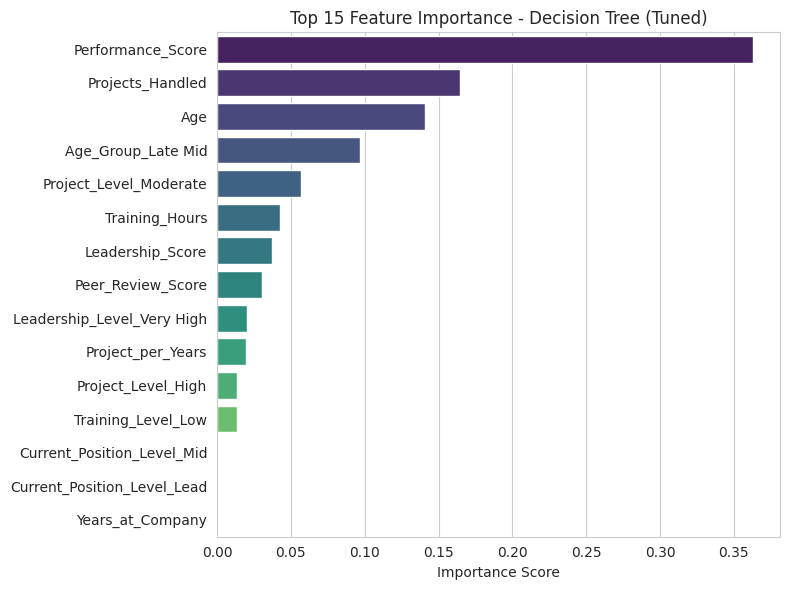

In [73]:
# --- Feature Importance: Decision Tree Tuned ---
model = dt_best1

# --- Feature Importance ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# tampilkan 15 teratas
top_features = feature_importance.head(15)
display(top_features)

# visualisasi
plt.figure(figsize=(8,6))
sns.barplot(y='Feature', x='Importance', data=top_features, palette='viridis')
plt.title('Top 15 Feature Importance - Decision Tree (Tuned)')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()

## SUMMARY OVERALL


DecisionTree Tuned LT tetap model paling balance, recall test cukup, overfit tidak terlalu tinggi.

Secara umum LT meningkatkan recall test sehingga minoritas positif (promosi) lebih terdeteksi.

Model Optimasi Terbaik – Decision Tree (GridSearch, Moderate Range)

Hasil Tuning:

Best Parameters:
criterion='gini', max_depth=5, min_samples_split=20, min_samples_leaf=4, class_weight=None

Best CV ROC-AUC: 0.660

class_weight = 'balanced'

Model ini cukup balance (tidak terlalu overfit karena max_depth 5 & min_samples_leaf 4) → terlihat dari evaluasi train-test.

Dapat dipakai untuk insight bisnis (misal melihat fitur penting untuk promosi), walaupun performa prediksi tidak sempurna.

Performance_Score & Projects_Handled wajib diperhatikan sebagai kriteria utama promosi sebab menjadi fitur paling dominan di kedua dataset (LT dan Non-LT), kontribusinya sekitar 0.36–0.39.

Artinya performa karyawan adalah indikator paling kuat untuk prediksi promosi.

Projects_Handled juga konsisten penting (~0.16–0.17), jadi jumlah proyek yang dikerjakan relevan secara signifikan.

Usia dan Tenure tetap relevan, tapi model Non-LT lebih menekankan kategori senioritas dibanding nilai numerik mentah.

Leadership & Training punya pengaruh kecil → bisa dipakai untuk fine-tuning keputusan promosi, bukan faktor utama.

# Stage 3 Evaluation

## A. Evaluasi Model

Interpretasi:

Kalau Train jauh lebih tinggi dari Test → indikasi overfitting.

Kalau Recall rendah tapi Accuracy tinggi → model masih kurang baik dalam menangkap karyawan yang layak promosi (FN tinggi).

=== MODEL EVALUATION REPORT ===


,Metric,Train,Test
0,Accuracy,0.671,0.559
1,Precision,0.669,0.316
2,Recall,0.675,0.436
3,F1-Score,0.672,0.366
4,ROC-AUC,0.671,0.523
5,MSE,0.329,0.441


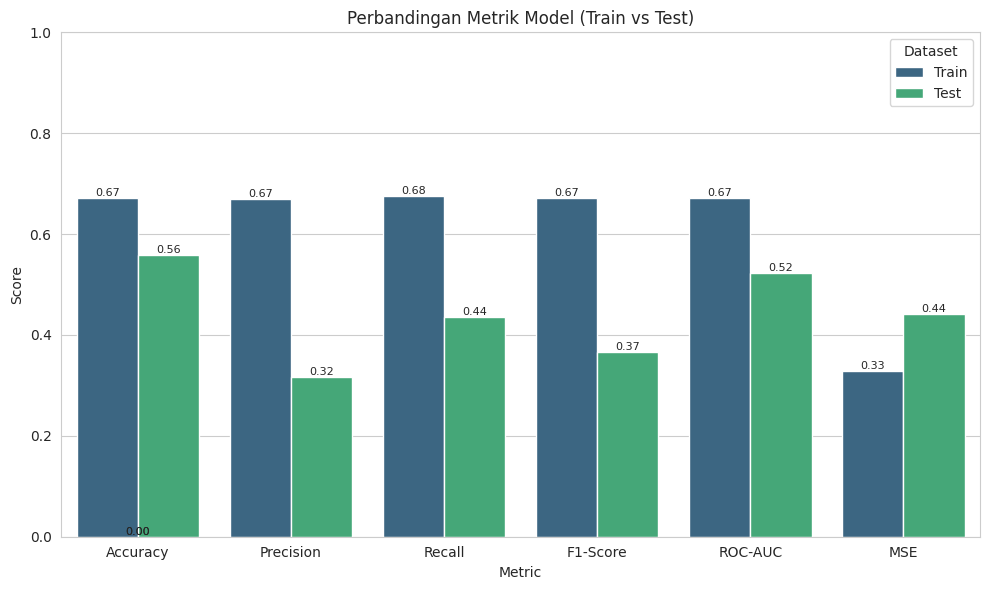

In [75]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, mean_squared_error, classification_report
)

# Misal model terbaik kamu:
model_final = dt_best1   # bisa diganti ke model terbaik
y_pred_train = model_final.predict(X_train_scaled)
y_pred_test = model_final.predict(X_test_scaled)

# Hitung metrik
metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "MSE"],
    "Train": [
        accuracy_score(y_train_bal, y_pred_train),
        precision_score(y_train_bal, y_pred_train),
        recall_score(y_train_bal, y_pred_train),
        f1_score(y_train_bal, y_pred_train),
        roc_auc_score(y_train_bal, y_pred_train),
        mean_squared_error(y_train_bal, y_pred_train)
    ],
    "Test": [
        accuracy_score(y_test, y_pred_test),
        precision_score(y_test, y_pred_test),
        recall_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test),
        roc_auc_score(y_test, y_pred_test),
        mean_squared_error(y_test, y_pred_test)
    ]
}

df_metrics = pd.DataFrame(metrics)
print("=== MODEL EVALUATION REPORT ===")
display(df_metrics.round(3))

# === Visualisasi Perbandingan Train vs Test ===
plt.figure(figsize=(10, 6))
df_melted = df_metrics.melt('Metric', var_name='Dataset', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Dataset', data=df_melted, palette='viridis')
plt.title('Perbandingan Metrik Model (Train vs Test)')
plt.ylim(0, 1)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}',
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

| **Metric**    | **Train** | **Test** | **Makna Praktis**                                                                           | **Interpretasi / % Perilaku Model**                                                                |
| ------------- | --------- | -------- | ------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------- |
| **Accuracy**  | 0.671     | 0.559    | Proporsi total prediksi benar (promosi & tidak promosi)                                     | Model hanya **benar 56%** pada data baru → ~44% keputusan promosi salah                            |
| **Precision** | 0.669     | 0.316    | Dari karyawan yang *diprediksi akan dipromosikan*, berapa yang benar-benar dipromosikan     | Hanya **31,6% prediksi promosi benar**, artinya **~68% false positive** (model terlalu optimistis) |
| **Recall**    | 0.675     | 0.436    | Dari seluruh karyawan yang *benar-benar dipromosikan*, berapa yang berhasil dideteksi model | Model hanya **menangkap 43,6% karyawan yang seharusnya dipromosikan** (banyak miss)                |
| **F1-Score**  | 0.672     | 0.366    | Rata-rata seimbang Precision & Recall                                                       | Performa keseluruhan moderat, **efektivitas model hanya ~37%** pada data baru                      |
| **ROC-AUC**   | 0.671     | 0.523    | Kemampuan membedakan antara yang dipromosikan vs tidak                                      | **0.523 ≈ acak (50%)**, model kurang mampu membedakan kelompok                                     |
| **MSE**       | 0.329     | 0.441    | Error rata-rata prediksi vs aktual                                                          | **Error meningkat di test**, tanda model sedikit overfit                                           |


## B. Explainability (SHAP)

Cocok untuk model Tree-based (Decision Tree, Random Forest, AdaBoost, XGBoost)

Makna:

Semakin tinggi nilai SHAP → semakin besar pengaruh fitur ke hasil prediksi.

Warna merah = dorong promosi, biru = menurunkan kemungkinan promosi.

In [93]:
import shap
import numpy as np

print("\n=== SHAP Force Plot - Safest Approach ===")
shap.initjs()

# Cek struktur SHAP values
print("Analyzing SHAP values structure...")

if isinstance(shap_values_to_plot, list):
    print(f"SHAP values is a list with {len(shap_values_to_plot)} elements")
    for i, arr in enumerate(shap_values_to_plot):
        print(f"  Element {i} shape: {arr.shape}")

    # Gunakan class 1, instance 0
    shap_vals = shap_values_to_plot[1][0]
else:
    shap_array = np.array(shap_values_to_plot)
    print(f"SHAP values shape: {shap_array.shape}")
    if len(shap_array.shape) == 3:
        shap_vals = shap_array[0, :, 1]  # instance 0, semua features, class 1
    elif len(shap_array.shape) == 2:
        shap_vals = shap_array[0, :]  # instance 0, semua features
    else:
        shap_vals = shap_array[0]  # instance 0

# Expected value
if isinstance(explainer.expected_value, (list, np.ndarray)):
    expected_val = explainer.expected_value[1]
else:
    expected_val = explainer.expected_value

print(f"Final SHAP values length: {len(shap_vals)}")
print(f"Number of features: {len(X_test_df.columns)}")

# Plot
shap.force_plot(
    expected_val,
    shap_vals,
    X_test_df.iloc[0].values,
    feature_names=X_test_df.columns.tolist()
)


=== SHAP Force Plot - Safest Approach ===


Analyzing SHAP values structure...
SHAP values shape: (188, 27, 2)
Final SHAP values length: 27
Number of features: 27


In [97]:
import shap
import numpy as np

print("\n=== SHAP Force Plot with .values Approach ===")
shap.initjs()

try:
    # Cek struktur shap_values_to_plot
    print(f"shap_values_to_plot type: {type(shap_values_to_plot)}")

    # Coba akses .values jika available
    if hasattr(shap_values_to_plot, 'values'):
        shap_values_data = shap_values_to_plot.values
        print(f"shap_values_to_plot.values shape: {shap_values_data.shape}")
    else:
        shap_values_data = shap_values_to_plot
        print(f"shap_values_to_plot shape: {np.array(shap_values_data).shape}")

    # Handle expected value
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        expected_val = explainer.expected_value[1]  # Class 1
    else:
        expected_val = explainer.expected_value

    print(f"Expected value: {expected_val}")

    # Coba beberapa pendekatan berbeda
    if hasattr(shap_values_data, 'shape'):
        if len(shap_values_data.shape) == 3:
            # Format: [instances, features, classes]
            shap_vals = shap_values_data[0, :, 1]  # Instance 0, semua features, class 1
        elif len(shap_values_data.shape) == 2:
            # Format: [instances, features] atau [instances, classes]
            if shap_values_data.shape[1] == len(X_test_df.columns):
                shap_vals = shap_values_data[0, :]  # Instance 0, semua features
            else:
                shap_vals = shap_values_data[0, 1]  # Instance 0, class 1
        else:
            shap_vals = shap_values_data[0]  # Instance 0
    else:
        # Jika berupa list
        if isinstance(shap_values_data, list):
            shap_vals = shap_values_data[1][0]  # Class 1, instance 0
        else:
            shap_vals = shap_values_data[0]  # Instance 0

    print(f"Final SHAP values length: {len(np.array(shap_vals).flatten())}")
    print(f"Number of features: {len(X_test_df.columns)}")

    # Force plot dengan .values
    shap.force_plot(
        expected_val,
        shap_vals,
        X_test_df.iloc[0:1],  # Gunakan 1 baris sebagai DataFrame
        plot_cmap="DrDb",
        matplotlib=False
    )

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


=== SHAP Force Plot with .values Approach ===


shap_values_to_plot type: <class 'numpy.ndarray'>
shap_values_to_plot shape: (188, 27, 2)
Expected value: 0.5
Final SHAP values length: 27
Number of features: 27


In [99]:
import shap
import numpy as np

print("\n=== SHAP Force Plot - Correct Structure ===")
shap.initjs()

try:
    # Struktur: (188 instances, 27 features, 2 classes)
    shap_values_data = shap_values_to_plot  # Shape: (188, 27, 2)

    # Expected value untuk class 1
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        expected_val = explainer.expected_value[1]  # Class 1
    else:
        expected_val = explainer.expected_value

    print(f"SHAP values shape: {shap_values_data.shape}")
    print(f"Expected value: {expected_val}")

    # Ambil instance pertama, semua features, class 1
    shap_vals_instance0_class1 = shap_values_data[0, :, 1]  # Instance 0, semua features, class 1

    # Features untuk instance pertama
    features_instance0 = X_test_df.iloc[0]

    print(f"SHAP values untuk plotting: {shap_vals_instance0_class1.shape}")
    print(f"Features untuk plotting: {features_instance0.shape}")

    # Force plot
    shap.force_plot(
        expected_val,
        shap_vals_instance0_class1,  # Shape: (27,)
        features_instance0,          # Shape: (27,)
        feature_names=X_test_df.columns.tolist(),
        matplotlib=False
    )

    print("Force plot berhasil dibuat!")

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


=== SHAP Force Plot - Correct Structure ===


SHAP values shape: (188, 27, 2)
Expected value: 0.5
SHAP values untuk plotting: (27,)
Features untuk plotting: (27,)
Force plot berhasil dibuat!


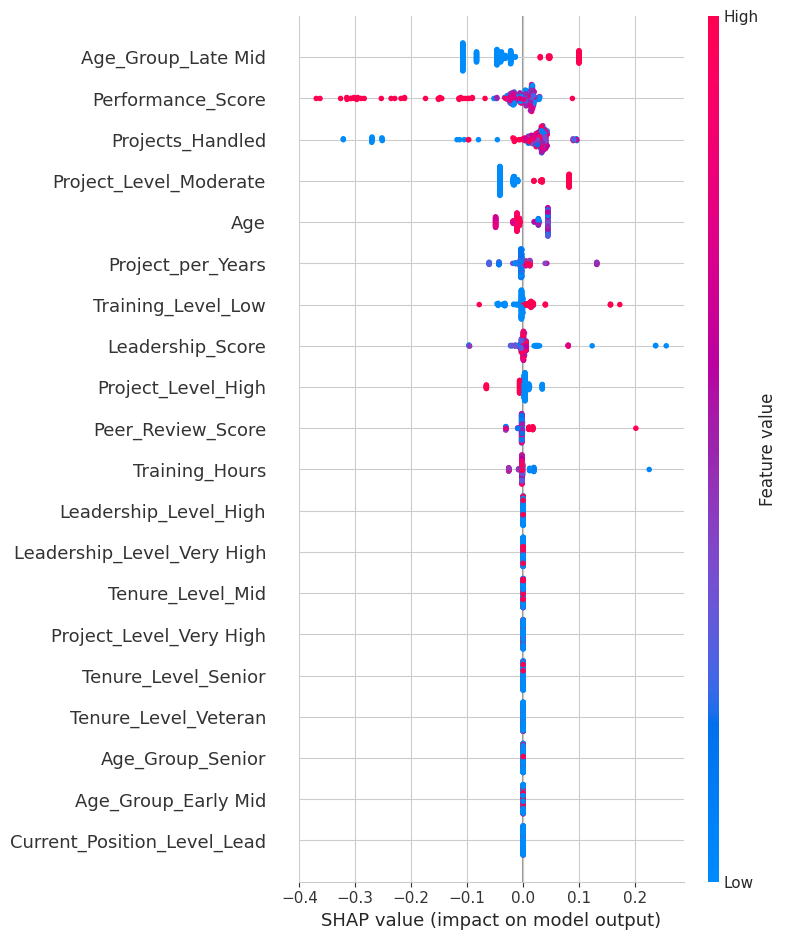

In [101]:
# Instance ke-10
instance_idx = 10
shap.force_plot(
    expected_val,
    shap_values_data[instance_idx, :, 1],
    X_test_df.iloc[instance_idx],
    feature_names=X_test_df.columns.tolist()
)

# Summary plot untuk class 1
shap.summary_plot(shap_values_data[:, :, 1], X_test_df, show=False)

| Fitur                  | Pola Warna & Posisi                   | Interpretasi                                                                                    |
| ---------------------- | ------------------------------------- | ----------------------------------------------------------------------------------------------- |
| **Performance_Score**  | Banyak titik merah di kanan, juga         | Nilai performa tinggi menaikkan peluang promosi (hubungan positif).                             |
| **Age_Group_Late Mid** | Titik cenderung netral hingga negatif | Usia menengah akhir sedikit menurunkan peluang promosi (mungkin karena sudah stabil di posisi). |
| **Projects_Handled**   | Merah di kanan, biru di kiri          | Lebih banyak proyek → lebih besar peluang promosi.                                              |
| **Training_Level_Low** | Biru di kanan, merah di kiri          | Training rendah justru bisa mengindikasikan bias model (tergantung feature lain).               |
| **Leadership_Score**   | Warna campur, penyebaran kecil        | Pengaruh ada tapi tidak terlalu besar.                                                          |


Pengaruh Performance_Score terhadap promosi tidak seragam di seluruh data — mungkin tergantung fitur lain (interaksi). - Titik merah di kiri → nilai performa tinggi menurunkan peluang promosi.

Kalau mayoritas karyawan berperforma tinggi tapi tidak dipromosikan (karena kuota promosi terbatas), model bisa “belajar” bahwa performa tinggi tidak selalu berarti promosi.

Pendorong Promosi (SHAP +)

* Performance_Score → dampak positif terbesar
* Projects_Handled, Peer_Review_Score, Leadership_Score → kontribusi positif kuat
* Training_Hours → sedikit pengaruh positif

Penghambat Promosi (SHAP –):
* Age_Group_Late Mid, Project_Level_Moderate → dampak negatif dominan
* Age, Training_Level_Low, Project_per_Years → menurunkan skor promosi

 Insight Bisnis

Karyawan yang cenderung dipromosikan:
* Performance tinggi
* Project & peer review bagus
* Leadership kuat
* Training memadai

Faktor penghambat:
* Usia “Late Mid” (mungkin stagnasi karier)
* Level project moderat atau training rendah

 Rekomendasi HR

A. Merit-Based Promotion: Fokuskan promosi pada performance & leadership, bukan usia. \
B. Career Path by Age:
* Late Mid → beri penghargaan non-promosi (bonus, proyek khusus).
* Junior → program percepatan karier\

C. Project & Training:
Dorong proyek lintas fungsi dan training personalisasi sesuai level

## C. Fairness dan Bias Assessment

Cocok untuk semua model klasifikasi, terutama yang digunakan untuk HR, promosi, kredit, atau rekrutmen.

Makna:

Kalau perbedaan Recall antar grup besar (>0.2) → indikasi bias model.

Misal, model lebih sering mempromosikan Mid-level daripada Junior, padahal performa sama.

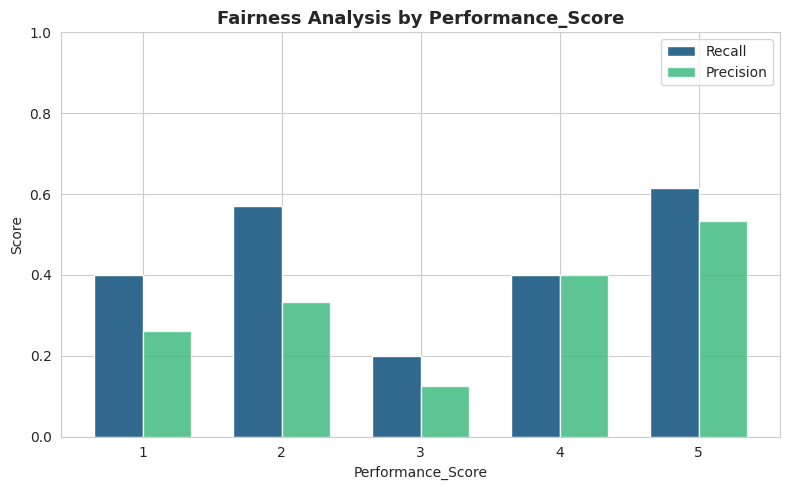


=== FAIRNESS REPORT ===


,Performance_Score,Recall,Precision
0,1,0.400,0.261
1,2,0.571,0.333
2,3,0.200,0.125
3,4,0.400,0.400
4,5,0.615,0.533


In [113]:
# === 3. FAIRNESS & BIAS ASSESSMENT ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import recall_score, precision_score

# === FAIRNESS ANALYSIS BY PERFORMANCE SCORE ===

# Gunakan Performance_Score sebagai sensitive attribute
sensitive_test = X_test['Performance_Score']

# Pastikan kategori (integer)
sensitive_test_clean = sensitive_test.round().astype(int)

# Buat dataframe fairness
fairness_data = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': y_pred_test,
    'Group': sensitive_test_clean.reset_index(drop=True)
})

# Hitung metrik per group
fairness_metrics = []
for g in sorted(fairness_data['Group'].unique()):
    df_g = fairness_data[fairness_data['Group'] == g]
    fairness_metrics.append({
        'Performance_Score': g,
        'Recall': recall_score(df_g['Actual'], df_g['Predicted'], zero_division=0),
        'Precision': precision_score(df_g['Actual'], df_g['Predicted'], zero_division=0)
    })

df_fairness = pd.DataFrame(fairness_metrics)

# === Visualisasi side-by-side ===
plt.figure(figsize=(8, 5))
palette = sns.color_palette("viridis", 5)

x = np.arange(len(df_fairness['Performance_Score']))  # posisi tiap grup
width = 0.35  # lebar batang

plt.bar(x - width/2, df_fairness['Recall'], width, label='Recall', color=palette[1])
plt.bar(x + width/2, df_fairness['Precision'], width, label='Precision', color=palette[3], alpha=0.8)

# Tambahkan label
plt.xticks(x, df_fairness['Performance_Score'])
plt.xlabel('Performance_Score')
plt.ylabel('Score')
plt.title('Fairness Analysis by Performance_Score', fontsize=13, weight='bold')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== FAIRNESS REPORT ===")
display(df_fairness.round(3))

| Performance_Score | Recall | Precision | Makna singkat                                                                                                                                                                   |
| ----------------- | ------ | --------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1**             | 0.400  | 0.261     | Dari karyawan dengan performance score 1, hanya 40% dari yang seharusnya dipromosikan berhasil dideteksi model (recall), dan hanya 26% prediksi promosi yang benar (precision). |
| **2**             | 0.571  | 0.333     | Kelompok ini relatif lebih baik, model bisa mendeteksi lebih banyak talenta (recall 57%), tapi akurasinya masih moderat.                                                        |
| **3**             | 0.200  | 0.125     | Paling lemah — model hampir tidak mengenali kelompok ini dengan benar (bias model bisa terjadi di kelompok ini).                                                                |
| **4**             | 0.400  | 0.400     | Seimbang tapi moderat, tidak terlalu tinggi juga.                                                                                                                               |
| **5**             | 0.615  | 0.533     | Paling tinggi — model cenderung **lebih akurat dan lebih responsif** terhadap kelompok dengan performance score tinggi.                                                         |



=== CONFUSION MATRIX ===
[[81 52]
 [31 24]]


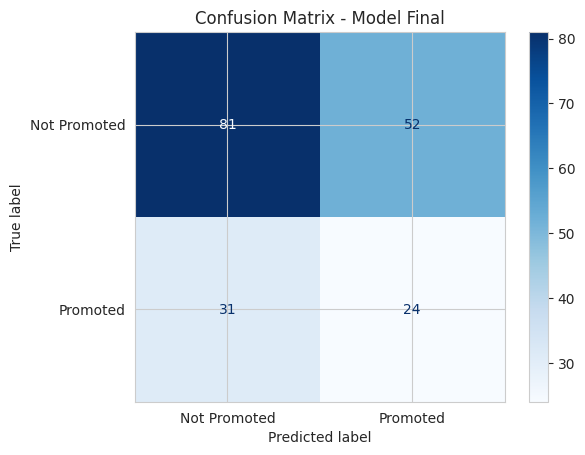

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prediksi pada data test
y_pred_test = model_final.predict(X_test_scaled)

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Tampilkan angka
print("\n=== CONFUSION MATRIX ===")
print(cm)

# Visualisasi dengan warna biru
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Promoted', 'Promoted'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Model Final")
plt.show()